In [2]:
ls()

character(0)

In [3]:
library(xgboost)

library(tgstat)
library(dplyr)
library(matrixStats)
library(pheatmap)
wd <- "/net/mraid20/export/tgdata/users/yonshap/proj/mmcortex"

setwd(wd)
library(MPRAnalyze)
library(data.table)
library(cowplot)
library(patchwork)
library(misha)
library(misha.ext)
gsetroot('/home/aviezerl/mm10')


mca <- readRDS('./output/mcatac/mmcortex_mcatac_feat_peaks_no_602_603.rds')

a_legc <- log2(1e-5 + t(t(mca@egc)/colSums(mca@egc)))

mcp <- dplyr::select(mca@peaks, chrom, start, end, peak_name)
library(metacell)

scdb_init('scdb', f=T)

mc <- scdb_mc('pl_cort')
mat <- scdb_mat('pl_cort')

tss <- gintervals.load('intervs.global.tss')

tads <- gintervals.load('intervs.global.tad_names')


Attaching package: 'dplyr'


The following object is masked from 'package:xgboost':

    slice


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'matrixStats'


The following object is masked from 'package:dplyr':

    count



Attaching package: 'data.table'


The following objects are masked from 'package:dplyr':

    between, first, last



Attaching package: 'patchwork'


The following object is masked from 'package:cowplot':

    align_plots



Attaching package: 'misha.ext'


The following object is masked from 'package:misha':

    gtrack.create_dirs


initializing scdb to scdb



In [4]:
nei_mcp_tads <- gintervals.neighbors(as.data.frame(mcp), tads, mindist = 0, maxdist = 0, maxneighbors = 1e+6)

In [5]:
orig_lib <- readr::read_tsv('./data/st_and_temporal_and_e14_shadow_enh_11-1-22.tsv')

ol_crs_df <- as.data.frame(cbind(do.call('rbind', stringr::str_split(orig_lib$rowname, '\\.|-')), orig_lib$rowname))
colnames(ol_crs_df) <- c('cell_type', 'pattern', 'number', 'crs_name')
head(ol_crs_df)

load('./output/mcatac/ct_peaks.rda')

nei_orig_ct <- gintervals.neighbors(dplyr::relocate(orig_lib, rowname, .after = end), ct_peaks, mindist = 0, maxdist = 0, maxneighbors = 1e+3)

mcmd <- readr::read_tsv('./BonevCollab/mcmd_pl_cort.tsv')
mcmd <- mcmd[!(as.numeric(mcmd$metacell) %in% 602:603),]

col_key <- tibble::deframe(unique(mcmd[,c('cell_type', 'color')]))
col_key

# Import data
mpra_annot <- read.table('./MPRA_data/st_and_temporal_and_e14_shadow_enh_11-1-22.tsv',header=T)
res <- read.table('./MPRA_data/MPRA_dev_090223.tsv',header=T)


# Correct p-value (BH)
res <- res[,c(grep('names',colnames(res)),grep('statistic',colnames(res)),grep('mad.score',colnames(res)),grep('pval.mad',colnames(res)),grep('enh_type',colnames(res)))]
res[,grep('pval.mad',colnames(res))] <- apply(res[,grep('pval.mad',colnames(res))],2,function(x){
  return(p.adjust(x,method='BH'))
})

Rows: 10905 Columns: 4
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (2): rowname, chrom
dbl (2): start, end

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


,cell_type,pattern,number,crs_name
,<chr>,<chr>,<chr>,<chr>
1,NSC,seqs_asc,NSC_2,NSC.seqs_asc.NSC_2
2,NSC,seqs_asc,NSC_3,NSC.seqs_asc.NSC_3
3,NSC,seqs_asc,NSC_6,NSC.seqs_asc.NSC_6
4,NSC,seqs_asc,NSC_7,NSC.seqs_asc.NSC_7
5,NSC,seqs_asc,NSC_9,NSC.seqs_asc.NSC_9
6,NSC,seqs_asc,NSC_10,NSC.seqs_asc.NSC_10


Rows: 1093 Columns: 11
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr (2): cell_type, color
dbl (9): metacell, E13, E14, E15, E16, E17, E18, mean_day, time_bin

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


iCPN_late iCPN/CfuPN iCPN_early        IPC   CPN_L5_6       SCPN     iCfuPN 
 "#CD3700"  "#FF3E96"  "#FA8072"  "#0000CD"  "#9FB6CD"  "#FFA500"  "#87CEFA" 
  CPN_L2-3      CthPN        NSC       OPCs Astrocytes    IPC_cyc 
 "#EED2EE"  "#8B4726"  "#00C5CD"  "#006400"  "#C4658D"  "#C0FF3E"

In [6]:
# df <- res[res$enh_type=='NSC',]
df <- res
df$temp <- gsub('seqs_','',as.data.frame(stringr::str_split(paste0(df$names), pattern ='\\.' , n = 3, simplify = TRUE))[,2])
df <- df[rowMins(as.matrix(df[,grep('NSC|IPC', grep('pval.mad',colnames(df), v=T),v=T)]), na.rm=T)<=0.1,]           #Select enhancers which are significant in at least one timepoint 

df_nsc <- df[,c('names', grep('NSC', grep('mad.score', colnames(df), v=T), v=T))]
rownames(df_nsc) <- df_nsc$names
df_ipc <- df[,c('names', grep('IPC', grep('mad.score', colnames(df), v=T), v=T))]
rownames(df_ipc) <- df_ipc$names
pltmt_nsc <- df_nsc[apply(df_nsc, 1, function(x) all(!is.na(x))),grep('_E1\\d', colnames(df_nsc))]
rn <- rownames(pltmt_nsc)
pltmt_nsc <- apply(pltmt_nsc, 2, function(x) log2(x - min(x) + 5e-1))              
rownames(pltmt_nsc) <- rn 
                   
                   
pltmt_ipc <- df_ipc[apply(df_ipc, 1, function(x) all(!is.na(x))),grep('_E1\\d', colnames(df_ipc))]
rn <- rownames(pltmt_ipc)
pltmt_ipc <- apply(pltmt_ipc, 2, function(x) log2(x - min(x) + 5e-1))              
rownames(pltmt_ipc) <- rn

In [7]:
orig_lib_f <- orig_lib[grep('chr', orig_lib$rowname, inv = T),]
e14_lib <- as.data.frame(stringr::str_split(gsub('E14_', '', grep('chr', orig_lib$rowname, v=T)), '-', simplify = T))
colnames(e14_lib) <- c('chrom', 'start', 'end')
e14_lib[,2:3] <- apply(e14_lib[,2:3], 2, as.numeric)


rownames(e14_lib) <- paste0('E14_', grep('chr', orig_lib$rowname, v=T))
shadow_lib <- as.data.frame(orig_lib[grep('chr', orig_lib$rowname),c('chrom', 'start', 'end')])
rownames(shadow_lib) <- paste0('shadow_', grep('chr', orig_lib$rowname, v=T))

orig_lib_a <- dplyr::bind_rows(orig_lib_f, tibble::rownames_to_column(e14_lib), tibble::rownames_to_column(shadow_lib))
save(orig_lib_a, file = './output/MPRA/orig_lib_w_e14_and_shadow_coords.rda')
seqs_tdf <- as.data.frame(stringr::str_split(orig_lib_a$rowname, '_|\\.', simplify = T))
seqs_tdf[seqs_tdf[,3] == '',3] <- NA
rownames(seqs_tdf) <- orig_lib_a$rowname
colnames(seqs_tdf) <- c('ct', 'seqs', 'temp', 'dummy1', 'dummy2')


In [8]:
# monuc_track <- gtrack.ls('seq.G_or_C')

# monuc_seq_coords <- gextract(monuc_track, intervals = as.data.frame(orig_lib_a[,c('chrom', 'start', 'end')]), colnames = gsub('seq\\.', '', monuc_track), iterator = 1)
# monuc_mat <- subset(monuc_seq_coords, select = -c(chrom, start, end, intervalID))
# monuc_per_peak <- as.data.frame(tgs_matrix_tapply(t(monuc_mat), monuc_seq_coords$intervalID, function(x) length(which(x == 1)))/266)
# rownames(monuc_per_peak) <- orig_lib_a$rowname
# monuc_per_peak$A_or_T <- 1 - monuc_per_peak$G_or_C
# save(monuc_per_peak, file = './output/MPRA/monuc_per_peak_orig_lib_w_e14_and_shadow.rda')

In [9]:
load(file = './output/MPRA/monuc_per_peak_orig_lib_w_e14_and_shadow.rda')

In [10]:
# dinuc_tracks <- gtrack.ls('seq\\.[ACGT]{2}$')

# dinucs_seq_coords <- gextract(dinuc_tracks, intervals = as.data.frame(orig_lib_a[,c('chrom', 'start', 'end')]), colnames = gsub('seq\\.', '', dinuc_tracks), iterator = 1)

# saveRDS(object = dinucs_seq_coords, file = './output/MPRA/dinucs_orig_lib.rds')
# dinucs_mat <- subset(dinucs_seq_coords, select = -c(chrom, start, end, intervalID))

# dinucs_per_peak <- tgs_matrix_tapply(t(dinucs_mat), dinucs_seq_coords$intervalID, function(x) length(which(x == 1)))/266
# rownames(dinucs_per_peak) <- orig_lib_a$rowname
# save(dinucs_per_peak, file = './output/MPRA/dinucs_per_peak_orig_lib_w_e14_and_shadow.rda')

In [11]:
load('./output/MPRA/dinucs_per_peak_orig_lib_w_e14_and_shadow.rda')

In [12]:
source('./scripts/util.r')

In [13]:
load('./output/sequence_modeling/xgb_cv_res.rda')
preds_all <- do.call('rbind', lapply(xgb_cv_res, function(x) x[['contrib_meth']]))
colnames(preds_all)

[1] "HOCOMOCO.MYB_HUMAN.H11MO.0.A"   "HOCOMOCO.OLIG2_HUMAN.H11MO.0.B"
 [3] "HOCOMOCO.GATA2_MOUSE.H11MO.0.A" "JOLMA.RFX4_di_DBD_1"           
 [5] "HOCOMOCO.TBP_MOUSE.H11MO.0.A"   "HOMER.JunD"                    
 [7] "JASPAR.Nr1H2"                   "HOCOMOCO.LEF1_HUMAN.H11MO.0.A" 
 [9] "HOCOMOCO.MYCN_MOUSE.H11MO.0.A"  "HOCOMOCO.NF2L1_HUMAN.H11MO.0.C"
[11] "HOMER.Olig2"                    "HOCOMOCO.SOX5_HUMAN.H11MO.0.C" 
[13] "JASPAR.TCF12"                   "JASPAR.NEUROG1"                
[15] "HOCOMOCO.TGIF1_HUMAN.H11MO.0.A" "JASPAR.EOMES"                  
[17] "NSC_ATAC"                       "methylation"                   
[19] "AA"                             "AC"                            
[21] "AG"                             "AT"                            
[23] "CA"                             "CC"                            
[25] "CG"                             "CT"                            
[27] "GC content"                     "prox_ATAC"                     
[29] "prox_RNA"                       "BIAS"

In [14]:
agg_id <- readr::read_csv('./scatac_data//aggregation_id.csv')
mca@cell_to_metacell$agg_id <- as.numeric(unlist(purrr::map(stringr::str_split(mca@cell_to_metacell$cell_id, '-'), 2)))
agg_id_day <- data.frame(cbind(1:14, rep(12:18, each = 2)))
colnames(agg_id_day) <- c('agg_id', 'day')
mca@cell_to_metacell$day <- agg_id_day$day[mca@cell_to_metacell$agg_id]
atac_mc_day <- table(mca@cell_to_metacell$metacell, mca@cell_to_metacell$day)
atac_mc_day_norm <- atac_mc_day/rowSums(atac_mc_day)
nsc_mcs <- which(mcmd$cell_type == 'NSC')
egc_by_day <- mca@egc[,nsc_mcs] %*% atac_mc_day_norm[nsc_mcs,]
egc_by_day_n <- t(t(egc_by_day)/colSums(egc_by_day))
colnames(egc_by_day_n) <- paste0('E', colnames(egc_by_day_n))
a_legc_by_day_n <- log2(1e-5 + egc_by_day_n)

Rows: 14 Columns: 2
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (1): sample_name
dbl (1): library_id

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Loading required package: mcATAC

i Parallelization enabled. Using 77 threads.


Attaching package: 'mcATAC'


The following object is masked _by_ '.GlobalEnv':

    mcmd




In [15]:
load(file.path(wd, 'output/sequence_modeling/enhflow_model_n_motif=16_w_clustering.rda'))

rename_prego_motifs <- function(model, tfs_in) {
    amd <- prego::all_motif_datasets()
    amou <- unique(amd[,c('motif', 'motif_orig')])
    motif_clustering <- model@params$distilled_features
    prego_motifs_renamed <- sapply(names(model@motif_models), function(cni) {
        candidates <- motif_clustering$feat[motif_clustering$clust == cni]
        candidates <- setNames(candidates, unlist(purrr::map(stringr::str_split(amou$motif_orig[match(candidates, amou$motif)], '_'), 1)))
        candidates_all <- candidates[tolower(names(candidates)) %in% tolower(tfs_in)]
        # candidates_feats <- candidates[tolower(names(candidates)) %in% tolower(intersect(tfs_in, feats))]
        # if (length(candidates_feats) > 0) {
        #     return(candidates_feats[[1]])
        # } else
        if (length(candidates_all) > 0) {
            return(candidates_all[[1]])
        } else {
            return(candidates[[1]])
        }
    })
    return(prego_motifs_renamed) 
}
tfs_in <- readLines(file.path(wd, 'output/metacell_model/tfs_in.txt'))
prego_motifs <- do.call('rbind', lapply(seq_along(tm_w_add_feat@motif_models), function(i) dplyr::mutate(tm_w_add_feat@motif_models[[i]]$pssm, motif = names(tm_w_add_feat@motif_models)[[i]])))
orig_lib_prego_ie <- prego::gextract_pwm(intervals = orig_lib_a[,c('chrom', 'start', 'end', 'rowname')], motifs = unique(prego_motifs$motif), dataset = prego_motifs)
orig_lib_prego_ie_mat <- subset(orig_lib_prego_ie, select = -c(chrom, start, end, rowname))
rownames(orig_lib_prego_ie_mat) <- orig_lib_prego_ie$rowname
prego_motifs_renamed <- rename_prego_motifs(tm_w_add_feat, tfs_in = tfs_in)
colnames(orig_lib_prego_ie_mat) <- prego_motifs_renamed[colnames(orig_lib_prego_ie_mat)]

In [16]:
dtest_ole_mtt_meth_0_atac_1 <- cbind(orig_lib_prego_ie_mat, 'NSC_ATAC' = mean(quantile(rowMeans(a_legc_by_day_n[rownames(preds_all),]), c(0,1))),'methylation' = 0, 
                                        dinucs_per_peak[rownames(orig_lib_prego_ie_mat),intersect(colnames(dinucs_per_peak), colnames(preds_all))], 
                                        'GC content' = 0.47, 'prox_ATAC' = 10, 'prox_RNA' = 10)

In [17]:
pred01 <- setNames(predict(xgb_cv_res[[1]]$bstDMatrix_meth, xgb.DMatrix(as.matrix(dtest_ole_mtt_meth_0_atac_1)), predcontrib=FALSE, predinteraction = FALSE), rownames(dtest_ole_mtt_meth_0_atac_1))

In [23]:
quantile(pred01)

0%        25%        50%        75%       100% 
-1.3026770 -0.7200676 -0.5390297 -0.3114557  0.8772879

In [18]:
inds_active_mpra <- multintersect(union(rownames(pltmt_nsc[rowMeans(pltmt_nsc) > quantile(rowMeans(pltmt_nsc), 0.75),]),
                             rownames(pltmt_ipc[rowMeans(pltmt_ipc) > quantile(rowMeans(pltmt_ipc), 0.75),])), rownames(pltmt_nsc), rownames(pltmt_ipc))

Length of arguments was 3679, 8683, 8573
Length of intersection is 3592


In [19]:
bins_en <- seq(-2, 2, l = 17)

In [20]:
bins_en

[1] -2.00 -1.75 -1.50 -1.25 -1.00 -0.75 -0.50 -0.25  0.00  0.25  0.50  0.75
[13]  1.00  1.25  1.50  1.75  2.00

In [20]:
plot_asterisks <- function(x, y, npi) {
        xl <- sapply(seq_along(npi), function(i) {
            if (npi[[i]] > 1) {
                return(seq(x[[i]] - 0.5*npi[[i]], x[[i]] + 0.5*npi[[i]], l = npi[[i]]))
            } else if (npi[[i]] == 1) {return(x[[i]])}
        })
        points(unlist(xl), rep(y, length(unlist(xl))), pch = 8, cex = 3, col = 'red', lwd= 2)
    }

In [21]:
ks_on_boxplot <- function(xvec, yvec, bins_vec, alternative = 'two.sided') {
    xvcnf <- cut(xvec, bins_vec)
    xvc <- droplevels(xvcnf)
    ksh <- ks.test(yvec[xvc %in% head(levels(xvc), 3)], yvec[xvc %in% tail(levels(xvc), 3)], alternative = alternative)
    print(ksh$p.value)
    LBINX <- match(head(levels(xvc), 3), levels(xvcnf))
    RBINX <- match(tail(levels(xvc), 3), levels(xvcnf))
    Y_LOW_LINE <- 3.3
    Y_HIGH_LINE <- 3.5
    LWD <- 2
    lines(LBINX[c(1,length(LBINX))], rep(Y_LOW_LINE, 2), col = 'red', lwd = LWD)
    lines(RBINX[c(1,length(RBINX))], rep(Y_LOW_LINE, 2), col = 'red', lwd = LWD)
    lines(rep(mean(LBINX), 2), c(Y_LOW_LINE,Y_HIGH_LINE), col = 'red', lwd = LWD)
    lines(rep(mean(RBINX), 2), c(Y_LOW_LINE,Y_HIGH_LINE), col = 'red', lwd = LWD)
    lines(c(mean(LBINX), mean(RBINX)), rep(Y_HIGH_LINE, 2), col = 'red', lwd = LWD)
    powvec <- 5*10**seq(-4,0,1)
    npi <- 4 - which.max(powvec > ksh$p.value)
    npi <- ifelse(npi < 1, 0, npi)
    npi <- ifelse(npi > 3, 3, npi)
    # print('this has run')
    plot_asterisks(mean(c(LBINX, RBINX)), Y_HIGH_LINE + 0.1, npi)
}

In [84]:
cni <- "NSC_E15_mad.score"
names_nc <- inds_active_mpra
y <- pltmt_nsc[names_nc,cni]
x <- pred01[names_nc]
xc <- cut(x, breaks = bins_en)
xvc <- droplevels(xc)
xc2 <- cut(x, )

boxplot(y[xvc %in% head(levels(xvc), 2)], at = 1, xlim = c(0.5,3.5))
boxplot(y[xvc %in% head(tail(levels(xvc), 7), 5)], at = 2, add = T)
boxplot(y[xvc %in% tail(levels(xvc), 2)], at =3, add = T)

ks.test(y[xvc %in% head(levels(xvc), 3)], y[xvc %in% tail(levels(xvc), 3)], alternative = 'less')

bins_en

levels(xvc)

options(repr.plot.width = 4)
options(repr.plot.height = 6)

boxplot(y ~ xvc)

In [73]:
options(repr.plot.width = 24)
options(repr.plot.height = 6)

In [22]:
# png('./output/MPRA/figs/MPRA_vs_xgb_pred_inds_active_by_day_test.png', h = 400, w = 2000, res = 50)
pdf('./output/MPRA/figs/MPRA_vs_xgb_pred_inds_active_by_day_test.pdf', h = 400/71, w = 2000/71)
par(mfrow = c(1,10), cex.axis = 2, cex.lab = 2, cex.main = 4, las = 2)
bins_en <- seq(-2, 2, l = 17)
par(col.main = col_key[['NSC']])
names_nc <- inds_active_mpra
marb <- 12
mart <- 3
marr <- 1
vvv <- sapply(colnames(pltmt_nsc), function(cni) {
    if (cni == colnames(pltmt_nsc)[[1]]) {par(mar = c(marb,5,mart,marr), cex.axis = 1.5)}
    else {par(mar = c(marb,2,mart,marr), cex.axis = 2)}
    boxplot_vec(xvec = pred01[names_nc], yvec = pltmt_nsc[names_nc,cni], nm = gsub('_mad.score', '', cni), bins = bins_en, 
                    ylab = '', ylim = c(-0.2,4.95), xlim = c(3.5,13), text_y_factor = 1., text_cex = 2, xaxt = 's', show_text = F)
    grid(lwd = 2, col = 'lightblue', lty = 2)
    ks_on_boxplot(xvec = pred01[names_nc], yvec = pltmt_nsc[names_nc,cni], bins_vec = bins_en, alternative = 'less')
    # bin_and_ks(xvec = pred01[names_nc], yvec = rowMeans(pltmt_nsc[names_nc,]), bins_ks = bins_ks, ks.alternative = 'less')
    title(ylab = 'NSC MPRA', line = 3)
})
# par(mar = c(12,8,1,3))
par(col.main = col_key[['IPC']])
vvv <- sapply(colnames(pltmt_ipc), function(cni) {
    if (cni == colnames(pltmt_ipc)[[1]]) {par(mar = c(marb,5,mart,marr), cex.axis = 1.5)}
    else {par(mar =  c(marb,2,mart,marr), cex.axis = 2)}
    boxplot_vec(xvec = pred01[names_nc], yvec = pltmt_ipc[names_nc,cni], nm = gsub('_mad.score', '', cni), bins = bins_en, 
        ylab = '', ylim = c(0.04,5.95), xlim = c(3.5,13), text_y_factor = 1., text_cex = 2, show_text = F)
    grid(lwd = 2, col = 'lightblue', lty = 2)
    ks_on_boxplot(xvec = pred01[names_nc], yvec = pltmt_ipc[names_nc,cni], bins_vec = bins_en, alternative = 'greater')
    # bin_and_ks(xvec = pred01[names_nc], yvec = rowMeans(pltmt_ipc[names_nc,]), bins_ks = bins_ks, ks.alternative = 'greater')
    title(ylab = 'IPC MPRA', line = 3)
    title(xlab = '<- NSC  xgboost prediction  IPC ->', line = 17)
})
dev.off()

In [22]:
# png('./output/MPRA/figs/test/astrocyte_specific_crs_vs_all_active_mpra_inds_ecdf.png', h = 400, w = 400)
pdf('./output/MPRA/figs/test/astrocyte_specific_crs_vs_all_active_mpra_inds_ecdf.pdf', h = 400/71, w = 400/71)

options(repr.plot.width = 6)
options(repr.plot.height = 6)
par(cex.lab = 2, cex.main = 1.5, cex.axis = 1.5, mar = c(5,5,3,1))
ksx <- apply(pltmt_nsc[intersect(rownames(pltmt_nsc), unique(nei_orig_ct$rowname[nei_orig_ct$type == 'astro_peak'])),], 1, function(x) sum((x - min(x))*(1:ncol(pltmt_nsc)))/sum((x - min(x))))
ksy <- apply(pltmt_nsc[setdiff(inds_active_mpra,unique(nei_orig_ct$rowname[nei_orig_ct$type == 'astro_peak'])),], 1, function(x) sum((x - min(x))*(1:ncol(pltmt_nsc)))/sum((x - min(x))))
plot(ecdf(ksx), do.points = F, col = col_key[['Astrocytes']], add = F, 
                xlab = 'Center of mass', ylab = 'ECDF', main = 'Astrocyte-specific CRSs are maximally\nactivated in later NSC MPRA time points', lwd = 2)
plot(ecdf(ksy), do.points =F, add = T, lwd = 2) 
legend('topleft', legend = c('Astrocyte-specific CRSs',paste0('n = ', length(ksx)), 'All active CRSs',paste0('n = ', length(ksy))), col = c(col_key[['Astrocytes']], NA, 'black', NA), lwd = 2)
dev.off()

In [23]:
ct_tracks <- c('mmcortex_nsc_marginal', 'mmcortex_ipc_marginal', 'mmcortex_cpn_l23_marginal','mmcortex_cpn_l56_marginal','mmcortex_cthpn_marginal','mmcortex_scpn_marginal')
ol_marg <- gextract(ct_tracks,intervals =  orig_lib_a[,c('chrom', 'start', 'end')], iterator = orig_lib_a[,c('chrom', 'start', 'end')])
len_ol_marg <- ol_marg$end - ol_marg$start
ol_marg$start[len_ol_marg < quantile(len_ol_marg, 0.5)] <- ol_marg$start[len_ol_marg < quantile(len_ol_marg, 0.5)] - 1
mcp_trim <- dplyr::mutate(mcp[,c('chrom', 'start', 'end')],start = start + 17, end = end - 17)
ct_tracks_on_manifold <- gextract(ct_tracks,intervals =  mcp_trim, iterator = mcp_trim)
ol_marg$rowname <- orig_lib_a$rowname[ol_marg$intervalID]
ol_marg[,ct_tracks] <- apply(ol_marg[,ct_tracks], 2, function(x) {y <- x; y[is.na(x)] <- 0; return(y)})
ol_marg$log_nsc <- log2(1e-5 + ol_marg$mmcortex_nsc_marginal/sum(ol_marg$mmcortex_nsc_marginal))
ol_marg$log_ipc <- log2(1e-5 + ol_marg$mmcortex_ipc_marginal/sum(ol_marg$mmcortex_ipc_marginal))
ol_marg$log_scpn <- log2(1e-5 + ol_marg$mmcortex_scpn_marginal/sum(ol_marg$mmcortex_scpn_marginal))
ol_marg$log_cthpn <- log2(1e-5 + ol_marg$mmcortex_cthpn_marginal/sum(ol_marg$mmcortex_cthpn_marginal))
ol_marg$log_cpn_l23 <- log2(1e-5 + ol_marg$mmcortex_cpn_l23_marginal/sum(ol_marg$mmcortex_cpn_l23_marginal))
ol_marg$log_cpn_l56 <- log2(1e-5 + ol_marg$mmcortex_cpn_l56_marginal/sum(ol_marg$mmcortex_cpn_l56_marginal))

THRSH_A <- -12
THRSH_B <- -14.5
new_class <- setNames(rep(NA, nrow(ol_marg)), ol_marg$rowname)

new_class[abs(ol_marg$log_nsc - ol_marg$log_ipc) < 1 & (ol_marg$log_ipc >= (-ol_marg$log_nsc + 2*THRSH_A))] <- 'A'
new_class[abs(ol_marg$log_nsc - ol_marg$log_ipc) < 1 & (ol_marg$log_ipc < (-ol_marg$log_nsc + 2*THRSH_A))] <- 'B'
new_class[abs(ol_marg$log_nsc - ol_marg$log_ipc) < 1 & (ol_marg$log_ipc < (-ol_marg$log_nsc + 2*THRSH_B))] <- 'C'
new_class[abs(ol_marg$log_nsc - ol_marg$log_ipc) >= 1 & ol_marg$log_nsc > ol_marg$log_ipc] <- 'NSC'
new_class[abs(ol_marg$log_nsc - ol_marg$log_ipc) >= 1 & ol_marg$log_nsc < ol_marg$log_ipc] <- 'IPC'

col_key[c('A', 'B', 'C')] <- c('orange', 'darkgreen', 'magenta')
ol_marg[match(names(new_class), ol_marg$rowname),'new_class'] <- new_class

ol_marg$pred01 <- pred01[ol_marg$rowname]

ol_marg$pred01_cut <- cut(ol_marg$pred01, breaks = quantile(ol_marg$pred01, c(0,0.2,0.8,1), na.rm = T), labels = c('pred NSC', 'pred und.', 'pred IPC'))

rm_nsc <- rowMeans(pltmt_nsc[,])
rm_ipc <- rowMeans(pltmt_ipc[,])

ol_marg$rm_nsc <- rm_nsc[ol_marg$rowname]

ol_marg$rm_ipc <- rm_ipc[ol_marg$rowname]

ol_marg$cut_rm_nsc <- cut(ol_marg$rm_nsc, breaks = quantile(ol_marg$rm_nsc, na.rm = T, seq(0,1,l=4)), labels = c('NSC MPRA lo', 'NSC MPRA mid', 'NSC MPRA hi'))
ol_marg$cut_rm_ipc <- cut(ol_marg$rm_ipc, breaks = quantile(ol_marg$rm_ipc, na.rm = T, seq(0,1,l=4)), labels = c('IPC MPRA lo', 'IPC MPRA mid', 'IPC MPRA hi'))

nei_ol_tads <- gintervals.neighbors(ol_marg, tads, mindist = 0, maxdist = 0, maxneighbors = 1e+6)

ol_marg$tad_name <- nei_ol_tads$tad_name[match(ol_marg$rowname, nei_ol_tads$rowname)]

In [24]:
neu_rn <- ol_marg$rowname[which(ol_marg$log_nsc <= -14 & ol_marg$log_ipc <= -14 & ol_marg$pred01 >= quantile(ol_marg$pred01, 0.7, na.rm = T) & ol_marg$cut_rm_ipc %in% paste0('IPC MPRA ', c('hi')))]
ipc_pc_rn <- ol_marg$rowname[which(ol_marg$log_nsc <= -14 & ol_marg$log_ipc >= -14 & ol_marg$pred01 >= quantile(ol_marg$pred01, 0.7, na.rm = T) & ol_marg$cut_rm_ipc %in% paste0('IPC MPRA ', c('hi')))]
anti_neu_rn <- ol_marg$rowname[which(ol_marg$log_nsc <= -14 & ol_marg$log_ipc <= -14 & ol_marg$pred01 <= quantile(ol_marg$pred01, 0.3, na.rm = T) & ol_marg$cut_rm_nsc %in% paste0('NSC MPRA ', c('hi')))]
nsc_pc_rn <- ol_marg$rowname[which(ol_marg$log_nsc >= -14 & ol_marg$log_ipc <= -14 & ol_marg$pred01 <= quantile(ol_marg$pred01, 0.3, na.rm = T) & ol_marg$cut_rm_nsc %in% paste0('NSC MPRA ', c('hi')))]

In [25]:
hi_nsc_lo_ipc_rn <- ol_marg$rowname[which(ol_marg$log_ipc <= -14 & ol_marg$log_nsc >= -14 & ol_marg$pred01 <= quantile(ol_marg$pred01, 0.7, na.rm = T) & ol_marg$pred01 >= quantile(ol_marg$pred01, 0.3, na.rm = T))]
hi_ipc_lo_nsc_rn <- ol_marg$rowname[which(ol_marg$log_nsc <= -14 & ol_marg$log_ipc >= -14 & ol_marg$pred01 >= quantile(ol_marg$pred01, 0.3, na.rm = T) & ol_marg$pred01 <= quantile(ol_marg$pred01, 0.7, na.rm = T))]
nc_neu_rn <- setdiff(ol_marg$rowname[which(ol_marg$log_nsc <= -14 & ol_marg$log_ipc <= -14)], union(neu_rn, anti_neu_rn))
nc_hi_ipc_lo_nsc_rn <- setdiff(ol_marg$rowname[which(ol_marg$log_nsc <= -14 & ol_marg$log_ipc >= -14)], union(hi_ipc_lo_nsc_rn, hi_nsc_lo_ipc_rn))
nc_hi_nsc_lo_ipc_rn <- setdiff(ol_marg$rowname[which(ol_marg$log_ipc <= -14 & ol_marg$log_nsc >= -14)], union(hi_ipc_lo_nsc_rn, hi_nsc_lo_ipc_rn))

In [26]:
ctxt_rn_intervs <- ol_marg[,c('chrom','start', 'end', 'rowname')]
ctxt_rn_intervs$peak_name <- mcATAC::peak_names(ctxt_rn_intervs, tad_based = F)

nei_orig_peaks <- gintervals.neighbors(orig_lib_a[,c('chrom', 'start', 'end', 'rowname')], 
                                       as.data.frame(mcp),  
                                       mindist = -30e+5, maxdist = 30e+5, maxneighbors = 1e+6)
nei_orig_peaks <- nei_orig_peaks[abs(nei_orig_peaks$dist) >= 1e+3,]

In [27]:
nei_ol_mcp <- gintervals.neighbors(orig_lib_a[,c('chrom', 'start', 'end', 'rowname')], 
                                       as.data.frame(mcp),  
                                       mindist = -500, maxdist = 500, maxneighbors = 1e+6)

In [28]:
# ctxt_rn_intervs$peak_name <- nei_orig_peaks$peak_name[match(ctxt_rn_intervs$rowname, nei_ol_mcp$rowname)]

In [29]:
ipc_marginal_peaks_umis <- Matrix::rowSums(mca@mat[nei_orig_peaks$peak_name,which(mcmd$cell_type == 'IPC')])
nsc_marginal_peaks_umis <- Matrix::rowSums(mca@mat[nei_orig_peaks$peak_name,which(mcmd$cell_type == 'NSC')])
nei_orig_peaks$is_anti_neu <- ifelse(nei_orig_peaks$rowname %in% anti_neu_rn, TRUE, FALSE)
nei_orig_peaks$is_ctxt_ipc <- ifelse(nei_orig_peaks$rowname %in% hi_ipc_lo_nsc_rn, TRUE, FALSE)
nei_orig_peaks$is_ctxt_nsc <- ifelse(nei_orig_peaks$rowname %in% hi_nsc_lo_ipc_rn, TRUE, FALSE)
nei_orig_peaks$is_neu <- ifelse(nei_orig_peaks$rowname %in% neu_rn, TRUE, FALSE)
nei_orig_peaks$is_ipc_pc <- ifelse(nei_orig_peaks$rowname %in% ipc_pc_rn, TRUE, FALSE)
nei_orig_peaks$is_nsc_pc <- ifelse(nei_orig_peaks$rowname %in% nsc_pc_rn, TRUE, FALSE)

nei_orig_peaks$ipc_atac_umis <- ipc_marginal_peaks_umis[nei_orig_peaks$peak_name]
nei_orig_peaks$nsc_atac_umis <- nsc_marginal_peaks_umis[nei_orig_peaks$peak_name]

In [30]:
nei_orig_peaks$tad_name_ol <- nei_ol_tads$tad_name[match(nei_orig_peaks$rowname, nei_ol_tads$rowname)]

In [31]:
nei_orig_peaks$tad_name_mcp <- nei_mcp_tads$tad_name[match(nei_orig_peaks$peak_name, nei_mcp_tads$peak_name)]

In [32]:
get_neighbor_mat <- function(order_metric_name, stat_type, nei_peak_df, crs_rownames, atac_umi_colname = 'ipc_atac_umis', bin_vec = seq(0, 30e+5, 1e+4)) {
    mat_inds <- which(nei_peak_df$rowname %in% crs_rownames)
    sks <- unique(nei_peak_df$rowname[mat_inds])
    metric <- sapply(seq_along(sks), function(i) {
        sk_inds <- which(nei_peak_df$rowname == sks[[i]])
        if (order_metric_name == 'com_abs') {
            y <- sum(abs(nei_peak_df$dist[sk_inds]) * nei_peak_df[sk_inds, atac_umi_colname])/sum(nei_peak_df[sk_inds, atac_umi_colname])
        } else if (order_metric_name == 'com') {
            y <- sum(nei_peak_df$dist[sk_inds] * nei_peak_df[sk_inds, atac_umi_colname])/sum(nei_peak_df[sk_inds, atac_umi_colname])
        } else if (order_metric_name == 'entropy') {
            dist_bins <- cut(nei_peak_df$dist[sk_inds], breaks = bin_vec)
            pv <- tapply(nei_peak_df[sk_inds, atac_umi_colname], dist_bins, sum, na.rm = T)
            pv[is.na(pv)] <- 0
            y <- entropy::entropy(pv)
        } else if (order_metric_name == 'sum') {
            y <- sum(nei_peak_df[sk_inds, atac_umi_colname])
        }
        else {stop('order_metric_name must be either: "com", "com_abs", "entropy" or "sum"')}
        return(y)
    })
    metric_ord <- order(metric)
    # print(length(metric_ord))
    # print(head(sks))
    # print(head(metric_ord))
    # print(head(sks[metric_ord]))
    neighbor_mat <- t(sapply(seq_along(metric_ord), function(i) {
        sk_inds <- which(nei_peak_df$rowname == sks[[metric_ord[[i]]]])
        dist_bins <- cut(nei_peak_df$dist[sk_inds], breaks = bin_vec)
        if (stat_type == 'sum_umis') {
            pv <- tapply(nei_peak_df[sk_inds, atac_umi_colname], dist_bins, sum, na.rm = T)   
        } else if (stat_type == 'num_neighbors') {
            pv <- table(dist_bins)
        }
        pv[is.na(pv)] <- 0
        return(pv)
    }))
    rownames(neighbor_mat) <- sks[metric_ord]
    colnames(neighbor_mat) <- head(bin_vec, -1)
    return(neighbor_mat)
}

In [35]:
neu_umi_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = nei_orig_peaks, crs_rownames = neu_rn)
ipc_pc_umi_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = nei_orig_peaks, crs_rownames = ipc_pc_rn)
ipc_ctxt_umi_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = nei_orig_peaks, crs_rownames = hi_ipc_lo_nsc_rn)
neu_num_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = nei_orig_peaks, crs_rownames = neu_rn)
ipc_pc_num_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = nei_orig_peaks, crs_rownames = ipc_pc_rn)
ipc_ctxt_num_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = nei_orig_peaks, crs_rownames = hi_ipc_lo_nsc_rn)
anti_neu_umi_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = nei_orig_peaks, crs_rownames = anti_neu_rn, atac_umi_colname = 'nsc_atac_umis')
nsc_pc_umi_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = nei_orig_peaks, crs_rownames = nsc_pc_rn, atac_umi_colname = 'nsc_atac_umis')
nsc_ctxt_umi_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = nei_orig_peaks, crs_rownames = hi_nsc_lo_ipc_rn, atac_umi_colname = 'nsc_atac_umis')
anti_neu_num_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = nei_orig_peaks, crs_rownames = anti_neu_rn, atac_umi_colname = 'nsc_atac_umis')
nsc_pc_num_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = nei_orig_peaks, crs_rownames = nsc_pc_rn, atac_umi_colname = 'nsc_atac_umis')
nsc_ctxt_num_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = nei_orig_peaks, crs_rownames = hi_nsc_lo_ipc_rn, atac_umi_colname = 'nsc_atac_umis')

In [43]:
neu_umi_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = neu_rn)
ipc_pc_umi_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = ipc_pc_rn)
ipc_ctxt_umi_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = hi_ipc_lo_nsc_rn)
neu_num_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = neu_rn)
ipc_pc_num_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = ipc_pc_rn)
ipc_ctxt_num_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = hi_ipc_lo_nsc_rn)
anti_neu_umi_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = anti_neu_rn, atac_umi_colname = 'nsc_atac_umis')
nsc_pc_umi_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = nsc_pc_rn, atac_umi_colname = 'nsc_atac_umis')
nsc_ctxt_umi_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = hi_nsc_lo_ipc_rn, atac_umi_colname = 'nsc_atac_umis')
anti_neu_num_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = anti_neu_rn, atac_umi_colname = 'nsc_atac_umis')
nsc_pc_num_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = nsc_pc_rn, atac_umi_colname = 'nsc_atac_umis')
nsc_ctxt_num_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = hi_nsc_lo_ipc_rn, atac_umi_colname = 'nsc_atac_umis')

[1] 291
[1] "NSC.seqs_asc.NSC_2657" "NSC.seqs_asc.NSC_3865" "NSC.seqs_asc.NSC_4422"
[4] "IPC.seqs_asc.IPC_386"  "IPC.seqs_asc.IPC_971"  "IPC.seqs_asc.IPC_1533"
[1]  29 251   7 110 196  69
[1] "IPC.seqs_desc.IPC_1590"              "E14_chr9-111920038-111920303"       
[3] "IPC.seqs_asc.IPC_1592"               "Mature.seqs_desc.Mature_neurons_753"
[5] "Mature.seqs_unc.Mature_neurons_914"  "Mature.seqs_desc.Mature_neurons_210"
[1] 229
[1] "IPC.seqs_asc.IPC_44"  "IPC.seqs_asc.IPC_391" "IPC.seqs_asc.IPC_398"
[4] "IPC.seqs_asc.IPC_440" "IPC.seqs_asc.IPC_493" "IPC.seqs_asc.IPC_520"
[1]  49 114 200 194 133 197
[1] "IPC.seqs_desc.IPC_221"              "Mature.seqs_unc.Mature_neurons_728"
[3] "E14_chr5-142407413-142407678"       "E14_chr5-36767351-36767616"        
[5] "E14_chr2-160618668-160618933"       "E14_chr9-28218601-28218866"        
[1] 368
[1] "IPC.seqs_asc.IPC_7"  "IPC.seqs_asc.IPC_16" "IPC.seqs_asc.IPC_22"
[4] "IPC.seqs_asc.IPC_27" "IPC.seqs_asc.IPC_34" "IPC.seqs_asc.IPC_45"
[1] 134 

In [36]:
rand_crs <- sample(ol_marg$rowname, round(mean(c(length(neu_rn),length(ipc_pc_rn),length(hi_ipc_lo_nsc_rn)))))

In [37]:
rand_umi_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = nei_orig_peaks, crs_rownames = rand_crs)
rand_umi_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'sum_umis', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = rand_crs)

In [38]:
rand_num_neighbor_mat <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = nei_orig_peaks, crs_rownames = rand_crs)
rand_num_neighbor_mat_tad <- get_neighbor_mat(order_metric_name = 'com_abs', stat_type = 'num_neighbors', nei_peak_df = dplyr::filter(nei_orig_peaks, tad_name_ol == tad_name_mcp), crs_rownames = rand_crs)

In [247]:
par(mfrow =c(1,2))
plot(rowSums(neu_umi_neighbor_mat[rownames(neu_umi_neighbor_mat_tad),], na.rm = T), rowSums(neu_umi_neighbor_mat_tad, na.rm = T))
abline(0,1,col='red')
plot(rowSums(ipc_pc_umi_neighbor_mat[rownames(ipc_pc_umi_neighbor_mat_tad),], na.rm = T), rowSums(ipc_pc_umi_neighbor_mat_tad, na.rm = T))
abline(0,1,col='red')

which(rowSums(neu_umi_neighbor_mat) < rowSums(neu_umi_neighbor_mat_tad))

which(rowSums(ipc_pc_umi_neighbor_mat) < rowSums(ipc_pc_umi_neighbor_mat_tad))

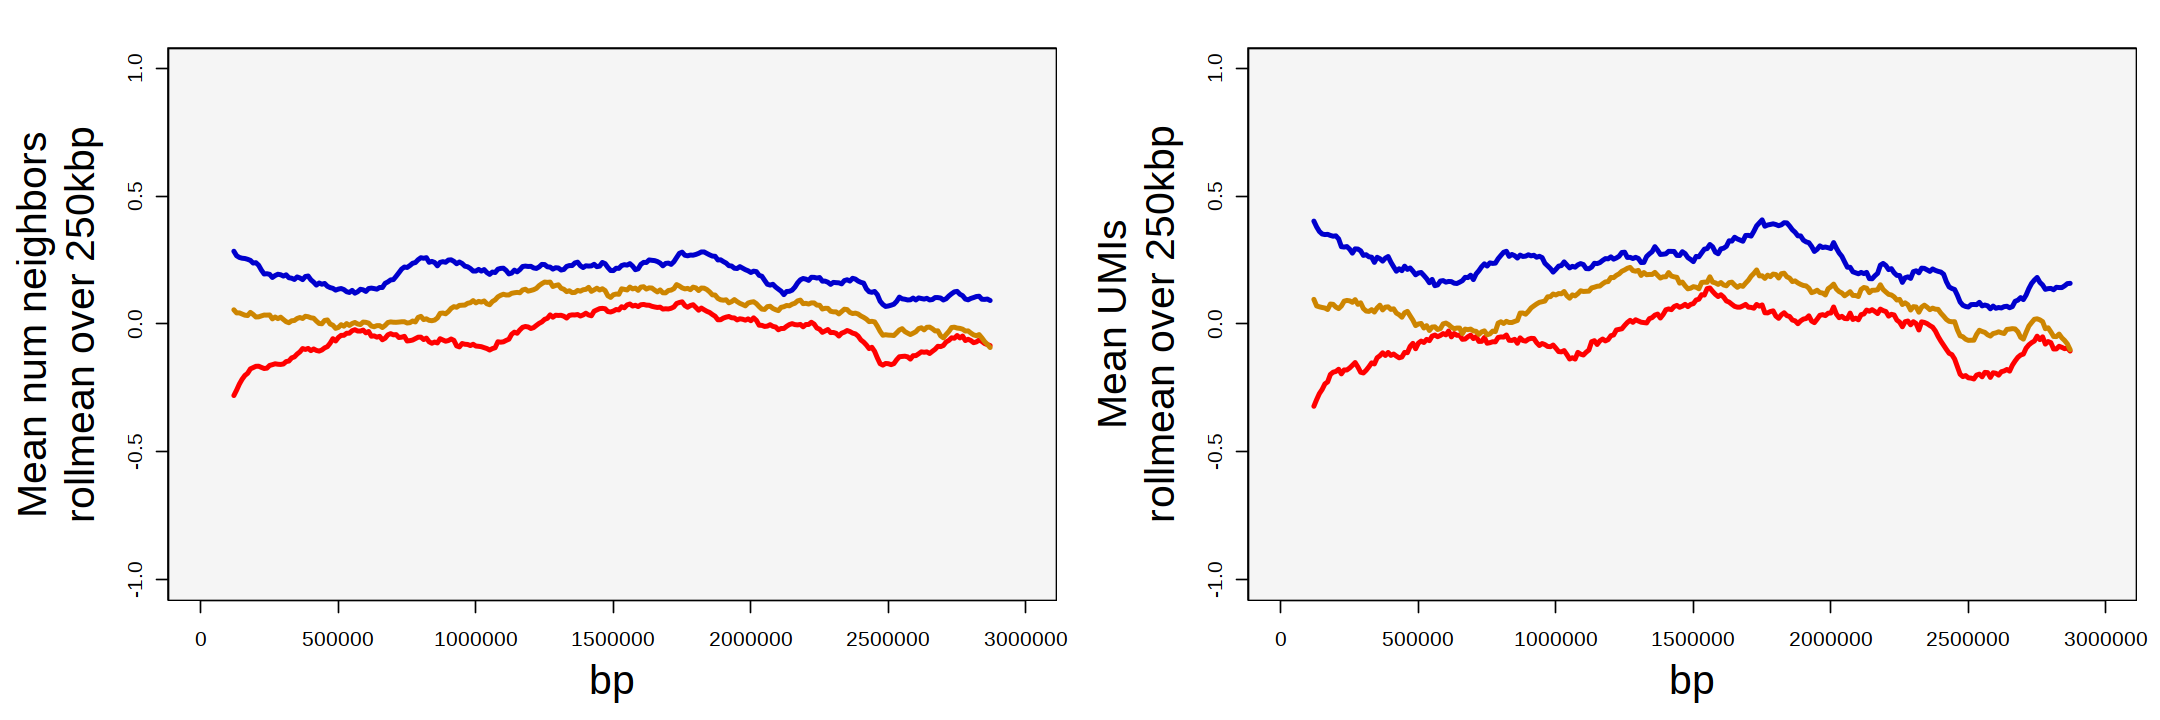

In [278]:
# png('./output/MPRA/figs/sum_nei_and_umis_over_50kbp_per_ipc_crs_categories.png', h = 400, w = 800)
# pdf('./output/MPRA/figs/sum_nei_and_umis_over_50kbp_per_ipc_crs_categories.pdf', h = 400/71, w = 800/71)
par(mfrow = c(1,2))
par(cex.lab = 2, mar = c(5,7,2,1))
K <- 25
LWD <- 3
bg_col <- 'whitesmoke'
x <- as.numeric(colnames(neu_num_neighbor_mat))
plot(x, zoo::rollmean(colMeans(neu_num_neighbor_mat), k = K, na.pad = T), col = 'white', ylim = c(-1,1), ylab = glue::glue('Mean num neighbors\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, log2(zoo::rollmean(colMeans(neu_num_neighbor_mat), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_num_neighbor_mat), k = K, na.pad = T)), col = 'red', lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_pc_num_neighbor_mat), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_num_neighbor_mat), k = K, na.pad = T)), col = col_key[['IPC']], lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_ctxt_num_neighbor_mat), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_num_neighbor_mat), k = K, na.pad = T)), col = 'orange3', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
par(cex.lab = 2, mar = c(5,7,2,1))
plot(x, zoo::rollmean(colMeans(neu_umi_neighbor_mat), k = K, na.pad = T), col = 'white', ylim = c(-1,1), ylab = glue::glue('Mean UMIs\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, log2(zoo::rollmean(colMeans(neu_umi_neighbor_mat), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_umi_neighbor_mat), k = K, na.pad = T)), col = 'red', lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_pc_umi_neighbor_mat), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_umi_neighbor_mat), k = K, na.pad = T)), col = col_key[['IPC']], lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_ctxt_umi_neighbor_mat), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_umi_neighbor_mat), k = K, na.pad = T)), col = 'orange3', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
# dev.off()

In [99]:
# png('./output/MPRA/figs/sum_nei_and_umis_over_50kbp_per_ipc_crs_categories.png', h = 400, w = 800)
pdf('./output/MPRA/figs/sum_nei_and_umis_over_50kbp_per_ipc_crs_categories_tad.pdf', h = 400/71, w = 800/71)
par(mfrow = c(1,2))
par(cex.lab = 2, mar = c(5,7,2,1))
K <- 25
LWD <- 3
bg_col <- 'whitesmoke'
x <- as.numeric(colnames(neu_num_neighbor_mat))
plot(x, zoo::rollmean(colMeans(neu_num_neighbor_mat_tad), k = K, na.pad = T), col = 'white', ylim = c(-10,.4), ylab = glue::glue('Log mean num neighbors\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, log2(zoo::rollmean(colMeans(neu_num_neighbor_mat_tad), k = K, na.pad = T)), col = 'red', lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_pc_num_neighbor_mat_tad), k = K, na.pad = T)), col = col_key[['IPC']], lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_ctxt_num_neighbor_mat_tad), k = K, na.pad = T)), col = 'orange3', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
par(cex.lab = 2, mar = c(5,7,2,1))
plot(x, log2(zoo::rollmean(colMeans(neu_umi_neighbor_mat_tad), k = K, na.pad = T)), col = 'white', ylim = c(0,16.3e+0), ylab = glue::glue('Log mean UMIs\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, log2(zoo::rollmean(colMeans(neu_umi_neighbor_mat_tad), k = K, na.pad = T)), col = 'red', lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_pc_umi_neighbor_mat_tad), k = K, na.pad = T)), col = col_key[['IPC']], lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_ctxt_umi_neighbor_mat_tad), k = K, na.pad = T)), col = 'orange3', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
dev.off()

png 
  2

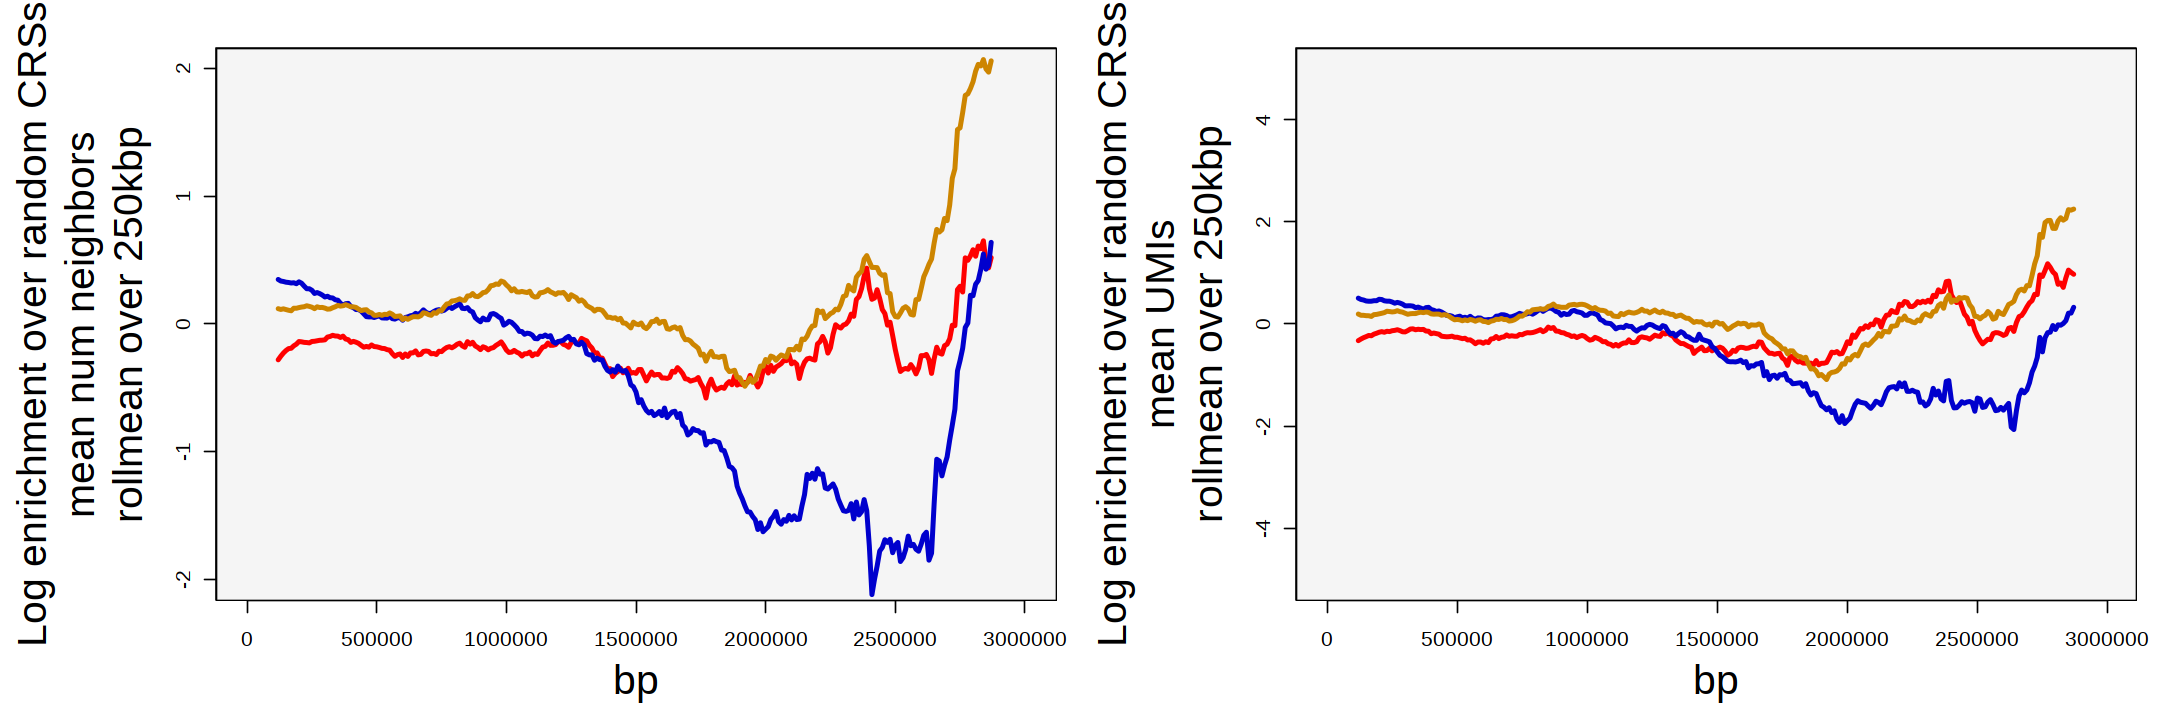

In [285]:
# png('./output/MPRA/figs/sum_nei_and_umis_over_50kbp_per_ipc_crs_categories.png', h = 400, w = 800)
# pdf('./output/MPRA/figs/sum_nei_and_umis_over_50kbp_per_ipc_crs_categories_tad.pdf', h = 400/71, w = 800/71)
par(mfrow = c(1,2))
par(cex.lab = 2, mar = c(5,9,2,1))
K <- 25
LWD <- 3
bg_col <- 'whitesmoke'
x <- as.numeric(colnames(neu_num_neighbor_mat))
plot(x, zoo::rollmean(colMeans(neu_num_neighbor_mat_tad), k = K, na.pad = T), xlim = c(0,3e+6), col = 'white', ylim = c(-2,2), ylab = glue::glue('Log enrichment over random CRSs\nmean num neighbors\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, log2(zoo::rollmean(colMeans(neu_num_neighbor_mat_tad), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_num_neighbor_mat_tad), k = K, na.pad = T)), col = 'red', lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_pc_num_neighbor_mat_tad), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_num_neighbor_mat_tad), k = K, na.pad = T)), col = col_key[['IPC']], lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_ctxt_num_neighbor_mat_tad), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_num_neighbor_mat_tad), k = K, na.pad = T)), col = 'orange3', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
par(cex.lab = 2, mar = c(5,9,2,1))
plot(x, log2(zoo::rollmean(colMeans(neu_umi_neighbor_mat_tad), k = K, na.pad = T)), col = 'white', ylim = c(-5,5), ylab = glue::glue('Log enrichment over random CRSs\nmean UMIs\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, log2(zoo::rollmean(colMeans(neu_umi_neighbor_mat_tad), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_umi_neighbor_mat_tad), k = K, na.pad = T)), col = 'red', lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_pc_umi_neighbor_mat_tad), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_umi_neighbor_mat_tad), k = K, na.pad = T)), col = col_key[['IPC']], lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(ipc_ctxt_umi_neighbor_mat_tad), k = K, na.pad = T)/zoo::rollmean(colMeans(rand_umi_neighbor_mat_tad), k = K, na.pad = T)), col = 'orange3', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
# dev.off()

In [39]:
# png('./output/MPRA/figs/sum_nei_and_umis_over_50kbp_per_nsc_crs_categories.png', h = 400, w = 800)
pdf('./output/MPRA/figs/test/sum_nei_and_umis_over_50kbp_per_nsc_crs_categories.pdf', h = 400/71, w = 800/71)
par(mfrow = c(1,2))
par(cex.lab = 2, mar = c(5,7,2,1))
K <- 25
LWD <- 3
bg_col <- 'whitesmoke'
x <- as.numeric(colnames(neu_num_neighbor_mat))
plot(x, zoo::rollmean(colMeans(neu_num_neighbor_mat), k = K, na.pad = T), col = 'white', ylim = c(0.8,1.62e+0), ylab = glue::glue('Mean num neighbors\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, zoo::rollmean(colMeans(anti_neu_num_neighbor_mat), k = K, na.pad = T), col = 'magenta', lwd = LWD)
lines(x, zoo::rollmean(colMeans(nsc_pc_num_neighbor_mat), k = K, na.pad = T), col = col_key[['NSC']], lwd = LWD)
lines(x, zoo::rollmean(colMeans(nsc_ctxt_num_neighbor_mat), k = K, na.pad = T), col = 'green', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
par(cex.lab = 2, mar = c(5,7,2,1))
plot(x, zoo::rollmean(colMeans(neu_umi_neighbor_mat), k = K, na.pad = T), col = 'white', ylim = c(8e+2,1.82e+3), ylab = glue::glue('Mean UMIs\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, zoo::rollmean(colMeans(anti_neu_umi_neighbor_mat), k = K, na.pad = T), col = 'magenta', lwd = LWD)
lines(x, zoo::rollmean(colMeans(nsc_pc_umi_neighbor_mat), k = K, na.pad = T), col = col_key[['NSC']], lwd = LWD)
lines(x, zoo::rollmean(colMeans(nsc_ctxt_umi_neighbor_mat), k = K, na.pad = T), col = 'green', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
dev.off()

png 
  2

In [40]:
# png('./output/MPRA/figs/sum_nei_and_umis_over_50kbp_per_nsc_crs_categories.png', h = 400, w = 800)
pdf('./output/MPRA/figs/test/sum_nei_and_umis_over_50kbp_per_nsc_crs_categories_tad.pdf', h = 400/71, w = 800/71)
par(mfrow = c(1,2))
par(cex.lab = 2, mar = c(5,7,2,1))
K <- 25
LWD <- 3
bg_col <- 'whitesmoke'
x <- as.numeric(colnames(neu_num_neighbor_mat))
plot(x, log2(zoo::rollmean(colMeans(neu_num_neighbor_mat_tad), k = K, na.pad = T)), col = 'white', ylim = c(-6,.1), 
     ylab = glue::glue('Log mean num neighbors\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, log2(zoo::rollmean(colMeans(anti_neu_num_neighbor_mat_tad), k = K, na.pad = T)), col = 'magenta', lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(nsc_pc_num_neighbor_mat_tad), k = K, na.pad = T)), col = col_key[['NSC']], lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(nsc_ctxt_num_neighbor_mat_tad), k = K, na.pad = T)), col = 'green', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
par(cex.lab = 2, mar = c(5,7,2,1))
plot(x, log2(zoo::rollmean(colMeans(neu_umi_neighbor_mat_tad), k = K, na.pad = T)), col = 'white', ylim = c(3.5,10.5), 
     ylab = glue::glue('Log mean UMIs\nrollmean over {10*K}kbp'), xlab = 'bp')
rect(par("usr")[1], par("usr")[3],
     par("usr")[2], par("usr")[4],
     col = bg_col)
lines(x, log2(zoo::rollmean(colMeans(anti_neu_umi_neighbor_mat_tad), k = K, na.pad = T)), col = 'magenta', lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(nsc_pc_umi_neighbor_mat_tad), k = K, na.pad = T)), col = col_key[['NSC']], lwd = LWD)
lines(x, log2(zoo::rollmean(colMeans(nsc_ctxt_umi_neighbor_mat_tad), k = K, na.pad = T)), col = 'green', lwd = LWD)
# axis(1, at = 1:100, labels = seq(-5e+4-1, 5e+4, l=100))
dev.off()

ERROR: Error in is.data.frame(x): object 'neu_num_neighbor_mat_tad' not found


In [ ]:
scdb_init(file.path(wd, 'scdb'), f=T)
mat <- scdb_mat('pl_cort')

mc <- scdb_mc('pl_cort')

source('./scripts/util.r')
nsc_pca <- proximal_chromatin_activity(peaks_of_interest = ctxt_rn_intervs[,c(1:3,5)],background_peaks = as.data.frame(mca@peaks[,c('chrom', 'start', 'end', 'peak_name')]), 
                                       restrict_to_tads = F,
                                       mc_sel = which(mcmd$cell_type == 'NSC'), mca = mca , mat_rna = mat , mc_rna = mc, tss = tss, tads = tads
                           )

ipc_pca <- proximal_chromatin_activity(peaks_of_interest = ctxt_rn_intervs[,c(1:3,5)],background_peaks = as.data.frame(mca@peaks[,c('chrom', 'start', 'end', 'peak_name')]),
                                       restrict_to_tads = F,
                                       mc_sel = which(mcmd$cell_type == 'IPC'), mca = mca , mat_rna = mat , mc_rna = mc, tss = tss, tads = tads
                           )
nsc_pca$rowname <- ctxt_rn_intervs$rowname[match(nsc_pca$peak_name, ctxt_rn_intervs$peak_name)]
nsc_pca$new_class <- ol_marg$new_class[match(nsc_pca$rowname, ol_marg$rowname)]
ipc_pca$rowname <- ctxt_rn_intervs$rowname[match(ipc_pca$peak_name, ctxt_rn_intervs$peak_name)]
ipc_pca$new_class <- ol_marg$new_class[match(ipc_pca$rowname, ol_marg$rowname)]
nsc_pca$is_ctxt <- ifelse(nsc_pca$rowname %in% hi_ipc_lo_nsc_rn, TRUE, FALSE)
ipc_pca$is_ctxt <- ifelse(ipc_pca$rowname %in% hi_nsc_lo_ipc_rn, TRUE, FALSE)
nsc_pca$is_neu <- ifelse(nsc_pca$rowname %in% neu_rn, TRUE, FALSE)
ipc_pca$is_neu <- ifelse(ipc_pca$rowname %in% neu_rn, TRUE, FALSE)
nsc_pca$is_anti_neu <- ifelse(nsc_pca$rowname %in% anti_neu_rn, TRUE, FALSE)
ipc_pca$is_anti_neu <- ifelse(ipc_pca$rowname %in% anti_neu_rn, TRUE, FALSE)

In [ ]:
nsc_pca_tad <- proximal_chromatin_activity(peaks_of_interest = ctxt_rn_intervs[,c(1:3,5)],background_peaks = as.data.frame(mca@peaks[,c('chrom', 'start', 'end', 'peak_name')]), 
                                           restrict_to_tads = T,
                                       mc_sel = which(mcmd$cell_type == 'NSC'), mca = mca , mat_rna = mat , mc_rna = mc, tss = tss, tads = tads
                           )

ipc_pca_tad <- proximal_chromatin_activity(peaks_of_interest = ctxt_rn_intervs[,c(1:3,5)],background_peaks = as.data.frame(mca@peaks[,c('chrom', 'start', 'end', 'peak_name')]),
                                           restrict_to_tads = T,
                                       mc_sel = which(mcmd$cell_type == 'IPC'), mca = mca , mat_rna = mat , mc_rna = mc, tss = tss, tads = tads
                           )
nsc_pca_tad$rowname <- ctxt_rn_intervs$rowname[match(nsc_pca$peak_name, ctxt_rn_intervs$peak_name)]
nsc_pca_tad$new_class <- ol_marg$new_class[match(nsc_pca$rowname, ol_marg$rowname)]
ipc_pca_tad$rowname <- ctxt_rn_intervs$rowname[match(ipc_pca$peak_name, ctxt_rn_intervs$peak_name)]
ipc_pca_tad$new_class <- ol_marg$new_class[match(ipc_pca$rowname, ol_marg$rowname)]
nsc_pca_tad$is_ctxt <- ifelse(nsc_pca$rowname %in% hi_ipc_lo_nsc_rn, TRUE, FALSE)
ipc_pca_tad$is_ctxt <- ifelse(ipc_pca$rowname %in% hi_nsc_lo_ipc_rn, TRUE, FALSE)
nsc_pca_tad$is_neu <- ifelse(nsc_pca$rowname %in% neu_rn, TRUE, FALSE)
ipc_pca_tad$is_neu <- ifelse(ipc_pca$rowname %in% neu_rn, TRUE, FALSE)
nsc_pca_tad$is_anti_neu <- ifelse(nsc_pca$rowname %in% anti_neu_rn, TRUE, FALSE)
ipc_pca_tad$is_anti_neu <- ifelse(ipc_pca$rowname %in% anti_neu_rn, TRUE, FALSE)

In [ ]:
plot_asterisks <- function(x, y, npi) {
    xl <- sapply(seq_along(npi), function(i) {
        if (npi[[i]] > 1) {
            return(seq(x[[i]] - 0.0751*npi[[i]], x[[i]] + 0.0751*npi[[i]], l = npi[[i]]))
        } else if (npi[[i]] == 1) {return(x[[i]])}
    })
    points(unlist(xl), rep(y, length(unlist(xl))), pch = 8, cex = 3, col = 'red', lwd= 3)
}

add_ks_stars_to_boxplot <- function(vec1, x1, vec2, x2, y_line, delta_y_asterisk, alternative = 'two.sided') {
    ksr <- ks.test(vec1, vec2, alternative = alternative)
    ksp <- ksr$p.value
    print(ksr$statistic)
    powvec <- 5*10**seq(-4,0,1)
    npi <- 4 - which.max(powvec > ksp)
    npi <- ifelse(npi < 1, 0, npi)
    npi <- ifelse(npi > 3, 3, npi)
    lines(c(x1, x2), rep(y_line, 2), col = 'red', lwd = 2)
    plot_asterisks(mean(c(x1, x2)), y_line+delta_y_asterisk, npi)
}

In [ ]:
par(mfrow = c(1,2))
locs <- seq(1,3,l=5)
boxplot(ipc_pca$atac_umi[ol_marg$rowname %in% nc_neu_rn], at = locs[[1]], add = F, xlim = c(0.5,2.75), ylim = c(0,1.75e+4), ylab = '', col = 'darkgray')
boxplot(ipc_pca$atac_umi[ipc_pca$is_neu == T], at = locs[[2]], add = T, col = 'red')
boxplot(ipc_pca$atac_umi[ipc_pca$rowname %in% nc_hi_ipc_lo_nsc_rn], at = locs[[3]], add = T, col = 'orange3')
boxplot(ipc_pca$atac_umi[match(ipc_pc_rn, ipc_pca$rowname)], at = locs[[4]], add = T, col = col_key[['IPC']])
add_ks_stars_to_boxplot(vec1 = ipc_pca$atac_umi[ipc_pca$is_neu == T], x1 = locs[[2]], vec2 = ipc_pca$atac_umi[match(ipc_pc_rn, ipc_pca$rowname)], x2 = locs[[4]],y_line = 16.5e+3, delta_y_asterisk = 8e+2)
add_ks_stars_to_boxplot(vec1 = ipc_pca$atac_umi[ipc_pca$is_neu == T], x1 = locs[[2]], vec2 = ipc_pca$atac_umi[ipc_pca$rowname %in% nc_hi_ipc_lo_nsc_rn], x2 = locs[[3]],y_line = 14.8e+3, delta_y_asterisk = 8e+2)

locs <- seq(1,3,l=5)
boxplot(ipc_pca_tad$atac_umi[ol_marg$rowname %in% nc_neu_rn], at = locs[[1]], add = F, xlim = c(0.5,2.75), ylim = c(0,1.75e+4), ylab = '', col = 'darkgray')
boxplot(ipc_pca_tad$atac_umi[ipc_pca_tad$is_neu == T], at = locs[[2]], add = T, col = 'red')
boxplot(ipc_pca_tad$atac_umi[ipc_pca_tad$rowname %in% nc_hi_ipc_lo_nsc_rn], at = locs[[3]], add = T, col = 'orange3')
boxplot(ipc_pca_tad$atac_umi[ipc_pca_tad$rowname %in% ipc_pc_rn], at = locs[[4]], add = T, col = col_key[['IPC']])
add_ks_stars_to_boxplot(vec1 = ipc_pca_tad$atac_umi[ipc_pca_tad$is_neu == T], x1 = locs[[2]], vec2 = ipc_pca_tad$atac_umi[match(ipc_pc_rn, ipc_pca_tad$rowname)], x2 = locs[[4]],y_line = 16.5e+3, delta_y_asterisk = 8e+2)
add_ks_stars_to_boxplot(vec1 = ipc_pca_tad$atac_umi[ipc_pca_tad$is_neu == T], x1 = locs[[2]], vec2 = ipc_pca_tad$atac_umi[ipc_pca_tad$rowname %in% nc_hi_ipc_lo_nsc_rn], x2 = locs[[3]],y_line = 14.8e+3, delta_y_asterisk = 8e+2)


In [ ]:
par(mfrow = c(1,2))
locs <- seq(1,3,l=5)
boxplot(nsc_pca$atac_umi[ol_marg$rowname %in% nc_neu_rn], at = locs[[1]], add = F, xlim = c(0.5,2.75), ylim = c(0,1.62e+4), ylab = '', col = 'darkgray')
boxplot(nsc_pca$atac_umi[nsc_pca$is_anti_neu == T], at = locs[[2]], add = T, col = 'magenta')
boxplot(nsc_pca$atac_umi[nsc_pca$rowname %in% nc_hi_nsc_lo_ipc_rn], at = locs[[3]], add = T, col = 'green')
boxplot(nsc_pca$atac_umi[match(nsc_pc_rn, nsc_pca$rowname)], at = locs[[4]], add = T, col = col_key[['NSC']])
grid(col = 'lightblue', lwd = 2, lty = 2)
add_ks_stars_to_boxplot(vec1 = nsc_pca$atac_umi[nsc_pca$is_anti_neu == T], x1 = locs[[2]], vec2 = nsc_pca$atac_umi[match(nsc_pc_rn, ipc_pca$rowname)], x2 = locs[[4]],y_line = 14.5e+3, delta_y_asterisk = 8e+2)
add_ks_stars_to_boxplot(vec1 = nsc_pca$atac_umi[nsc_pca$is_anti_neu == T], x1 = locs[[2]], vec2 = nsc_pca$atac_umi[nsc_pca$rowname %in% nc_hi_nsc_lo_ipc_rn], x2 = locs[[3]],y_line = 12.8e+3, delta_y_asterisk = 8e+2)

locs <- seq(1,3,l=5)
boxplot(nsc_pca_tad$atac_umi[ol_marg$rowname %in% nc_neu_rn], at = locs[[1]], add = F, xlim = c(0.5,2.75), ylim = c(0,1.62e+4), ylab = '', col = 'darkgray')
boxplot(nsc_pca_tad$atac_umi[nsc_pca_tad$is_anti_neu == T], at = locs[[2]], add = T, col = 'magenta')
boxplot(nsc_pca_tad$atac_umi[nsc_pca_tad$rowname %in% nc_hi_nsc_lo_ipc_rn], at = locs[[3]], add = T, col = 'green')
boxplot(nsc_pca_tad$atac_umi[match(nsc_pc_rn, nsc_pca_tad$rowname)], at = locs[[4]], add = T, col = col_key[['NSC']])
grid(col = 'lightblue', lwd = 2, lty = 2)
add_ks_stars_to_boxplot(vec1 = nsc_pca_tad$atac_umi[nsc_pca_tad$is_anti_neu == T], x1 = locs[[2]], vec2 = nsc_pca_tad$atac_umi[match(nsc_pc_rn, nsc_pca_tad$rowname)], x2 = locs[[4]],y_line = 14.5e+3, delta_y_asterisk = 8e+2)
add_ks_stars_to_boxplot(vec1 = nsc_pca_tad$atac_umi[nsc_pca_tad$is_anti_neu == T], x1 = locs[[2]], vec2 = nsc_pca_tad$atac_umi[nsc_pca$rowname %in% nc_hi_nsc_lo_ipc_rn], x2 = locs[[3]],y_line = 12.8e+3, delta_y_asterisk = 8e+2)


In [ ]:

# png('./output/MPRA/figs/atac_mpra_prox_atac_umi_of_potentially_silenced_crs_groups.png', h = 750, w = 1550)
pdf('./output/MPRA/figs/test/atac_mpra_prox_atac_umi_of_potentially_silenced_crs_groups.pdf', h = 750/71, w = 1550/71)


####### IPC plot ######
######################


nri <- ol_marg$rowname %in% neu_rn
ord <- order(as.numeric(nri))
layout(mat = rbind(c(1,1,1,2,2,3,3,4,4,5,5),c(6,6,6,7,7,8,8,9,9,10,10)))
par(cex.lab = 2.5, cex.axis = 1.5, mar = c(5,5,1,1))

CEX <- 0.75
plot(ol_marg$log_nsc[ord], ol_marg$log_ipc[ord], pch = 16, col = ifelse(ol_marg$rowname[ord] %in% neu_rn, 'red', 'black'), xlab = 'NSC ATAC', ylab = 'IPC ATAC', cex = ifelse(ol_marg$rowname[ord] %in% neu_rn, 2*CEX, CEX))
points(ol_marg$log_nsc[match(hi_ipc_lo_nsc_rn, ol_marg$rowname)], ol_marg$log_ipc[match(hi_ipc_lo_nsc_rn, ol_marg$rowname)], pch = 16, col = 'orange3', cex = 2*CEX)
points(ol_marg$log_nsc[match(ipc_pc_rn, ol_marg$rowname)], ol_marg$log_ipc[match(ipc_pc_rn, ol_marg$rowname)], pch = 16, col = col_key[['IPC']], cex = 2*CEX)
legend('bottomright', col = c('red', col_key[['IPC']], 'orange3'), legend = paste0('n = ', c(length(neu_rn), length(ipc_pc_rn), length(hi_ipc_lo_nsc_rn))), pch = 15, cex = 2)


par(mar = c(4,5,1,1))
locs <- seq(1,3.5,0.5)
boxplot(ol_marg$pred01[ol_marg$rowname %in% neu_rn], at = locs[[1]], col = 'red', add = F, xlim = c(0.75,2.25), ylim = c(-1.2,.51), ylab = 'NSC <-    xgb pred    -> IPC')
boxplot(ol_marg$pred01[ol_marg$rowname %in% ipc_pc_rn], at = locs[[2]], col = col_key[['IPC']], add = T)
boxplot(ol_marg$pred01[ol_marg$rowname %in% hi_ipc_lo_nsc_rn], at = locs[[3]], col = 'orange3', add = T)

par(mar = c(5,5,1,1))
locs <- seq(1,2.5,0.5)
boxplot(ol_marg$rm_ipc[ol_marg$rowname %in% neu_rn], at = locs[[1]], col = 'red', add = F, xlim = c(0.75,2.25), ylim = c(0.9,2.7), ylab = 'MPRA score')
boxplot(ol_marg$rm_ipc[ol_marg$rowname %in% ipc_pc_rn], at = locs[[2]], col = col_key[['IPC']], add = T)
boxplot(ol_marg$rm_ipc[ol_marg$rowname %in% hi_ipc_lo_nsc_rn], at = locs[[3]], col = 'orange3', add = T)

locs <- seq(1,3,l=5)
boxplot(ipc_pca$atac_umi[ol_marg$rowname %in% nc_neu_rn], at = locs[[1]], add = F, xlim = c(0.5,2.75), ylim = c(0,1.75e+4), ylab = '', col = 'darkgray')
boxplot(ipc_pca$atac_umi[ipc_pca$is_neu == T], at = locs[[2]], add = T, col = 'red')
boxplot(ipc_pca$atac_umi[ipc_pca$rowname %in% nc_hi_ipc_lo_nsc_rn], at = locs[[3]], add = T, col = 'orange3')
boxplot(ipc_pca$atac_umi[match(ipc_pc_rn, ipc_pca$rowname)], at = locs[[4]], add = T, col = col_key[['IPC']])
add_ks_stars_to_boxplot(vec1 = ipc_pca$atac_umi[ipc_pca$is_neu == T], x1 = locs[[2]], vec2 = ipc_pca$atac_umi[match(ipc_pc_rn, ipc_pca$rowname)], x2 = locs[[4]],y_line = 16.5e+3, delta_y_asterisk = 8e+2)
add_ks_stars_to_boxplot(vec1 = ipc_pca$atac_umi[ipc_pca$is_neu == T], x1 = locs[[2]], vec2 = ipc_pca$atac_umi[ipc_pca$rowname %in% nc_hi_ipc_lo_nsc_rn], x2 = locs[[3]],y_line = 14.8e+3, delta_y_asterisk = 8e+2)


grid(col = 'lightblue', lwd = 2, lty = 2)
title(ylab = 'Proximal ATAC UMI (50kbp)', line = 3)

locs <- seq(1,5,l=9)

boxplot(ipc_pca$rna_umi[ol_marg$rowname %in% nc_neu_rn], at = locs[[1]], add = F, xlim = c(0.5,2.75), ylim = c(0,1.462e+5), ylab = '', col = 'darkgray', yaxt = 'n')
boxplot(ipc_pca$rna_umi[ipc_pca$is_neu == T], at = locs[[2]], add = T, col = 'red', yaxt = 'n')
boxplot(ipc_pca$rna_umi[ipc_pca$rowname %in% nc_hi_ipc_lo_nsc_rn], at = locs[[3]], add = T, col = 'orange3', yaxt = 'n')
# boxplot(ipc_pca$atac_umi[ipc_pca$is_ctxt == T], at = locs[[4]], add = T, col = 'green')
boxplot(ipc_pca$rna_umi[match(ipc_pc_rn, ipc_pca$rowname)], at = locs[[4]], add = T, col = col_key[['IPC']], yaxt = 'n')
add_ks_stars_to_boxplot(vec1 = ipc_pca$rna_umi[ipc_pca$is_neu == T], x1 = locs[[2]], vec2 = ipc_pca$rna_umi[match(ipc_pc_rn, ipc_pca$rowname)], x2 = locs[[4]],y_line = 1.35e+5, delta_y_asterisk = 7e+3)
add_ks_stars_to_boxplot(vec1 = ipc_pca$rna_umi[ipc_pca$is_neu == T], x1 = locs[[2]], vec2 = ipc_pca$rna_umi[ipc_pca$rowname %in% nc_hi_ipc_lo_nsc_rn], x2 = locs[[3]],y_line = 1.18e+5, delta_y_asterisk = 7e+3)
axis(2, at = seq(0,1.5e+5, 5e+4), labels = signif(seq(0,1.5e+5, 5e+4), 2))
title(ylab = 'Proximal RNA UMI (500kbp)', line = 3)


####### NSC plot ######
######################
CEX <- 0.75
nri <- ol_marg$rowname %in% anti_neu_rn
ord <- order(as.numeric(nri))
plot(ol_marg$log_nsc[ord], ol_marg$log_ipc[ord], pch = 16, col = ifelse(ol_marg$rowname[ord] %in% anti_neu_rn, 'magenta', 'black'), xlab = 'NSC ATAC', ylab = 'IPC ATAC', cex = ifelse(ol_marg$rowname[ord] %in% anti_neu_rn, 2*CEX, CEX))
points(ol_marg$log_nsc[match(hi_nsc_lo_ipc_rn, ol_marg$rowname)], ol_marg$log_ipc[match(hi_nsc_lo_ipc_rn, ol_marg$rowname)], pch = 16, col = 'green', cex = 2*CEX)
points(ol_marg$log_nsc[match(nsc_pc_rn, ol_marg$rowname)], ol_marg$log_ipc[match(nsc_pc_rn, ol_marg$rowname)], pch = 16, col = col_key[['NSC']], cex = 2*CEX)
legend('bottomright', col = c('magenta', col_key[['NSC']], 'green'), legend = paste0('n = ', c(length(anti_neu_rn), length(nsc_pc_rn), length(hi_nsc_lo_ipc_rn))), pch = 15, cex = 2)


par(mar = c(4,5,1,1))
locs <- seq(1,3,0.5)
boxplot(ol_marg$pred01[ol_marg$rowname %in% anti_neu_rn], at = locs[[1]], col = 'magenta', add = F, xlim = c(0.75,2.25), ylim = c(-1.2,.51), ylab = 'NSC <-    xgb pred    -> IPC')
boxplot(ol_marg$pred01[ol_marg$rowname %in% nsc_pc_rn], at = locs[[2]], col = col_key[['NSC']], add = T)
boxplot(ol_marg$pred01[ol_marg$rowname %in% hi_nsc_lo_ipc_rn], at = locs[[3]], col = 'green', add = T)

par(mar = c(5,5,1,1))
locs <- seq(1,3,0.5)
boxplot(ol_marg$rm_nsc[ol_marg$rowname %in% anti_neu_rn], at = locs[[1]], col = 'magenta', add = F, xlim = c(0.75,2.35), ylim = c(0.9,2.7), ylab = 'MPRA score')
boxplot(ol_marg$rm_nsc[ol_marg$rowname %in% nsc_pc_rn], at = locs[[2]], col = col_key[['NSC']], add = T)
boxplot(ol_marg$rm_nsc[ol_marg$rowname %in% hi_nsc_lo_ipc_rn], at = locs[[3]], col = 'green', add = T)
text(c(1.5,2.75), rep(0.43,2), labels = paste0('in ', c('IPC', 'NSC')), xpd = T, col = 'darkgray', cex = 2)

locs <- seq(1,3,l=5)
boxplot(nsc_pca$atac_umi[ol_marg$rowname %in% nc_neu_rn], at = locs[[1]], add = F, xlim = c(0.5,2.75), ylim = c(0,1.62e+4), ylab = '', col = 'darkgray')
boxplot(nsc_pca$atac_umi[nsc_pca$is_anti_neu == T], at = locs[[2]], add = T, col = 'magenta')
boxplot(nsc_pca$atac_umi[nsc_pca$rowname %in% nc_hi_nsc_lo_ipc_rn], at = locs[[3]], add = T, col = 'green')
boxplot(nsc_pca$atac_umi[match(nsc_pc_rn, nsc_pca$rowname)], at = locs[[4]], add = T, col = col_key[['NSC']])
grid(col = 'lightblue', lwd = 2, lty = 2)
add_ks_stars_to_boxplot(vec1 = nsc_pca$atac_umi[nsc_pca$is_anti_neu == T], x1 = locs[[2]], vec2 = nsc_pca$atac_umi[match(nsc_pc_rn, ipc_pca$rowname)], x2 = locs[[4]],y_line = 14.5e+3, delta_y_asterisk = 8e+2)
add_ks_stars_to_boxplot(vec1 = nsc_pca$atac_umi[nsc_pca$is_anti_neu == T], x1 = locs[[2]], vec2 = nsc_pca$atac_umi[nsc_pca$rowname %in% nc_hi_nsc_lo_ipc_rn], x2 = locs[[3]],y_line = 12.8e+3, delta_y_asterisk = 8e+2)


title(ylab = 'Proximal ATAC UMI (50kbp)', line = 3)

locs <- seq(1,3,l=5)

boxplot(nsc_pca$rna_umi[ol_marg$rowname %in% nc_neu_rn], at = locs[[1]], add = F, xlim = c(0.5,2.75), ylim = c(0,1.262e+5), ylab = '', col = 'darkgray', yaxt = 'n')
boxplot(nsc_pca$rna_umi[nsc_pca$is_anti_neu == T], at = locs[[2]], add = T, col = 'magenta', yaxt = 'n')
boxplot(nsc_pca$rna_umi[nsc_pca$rowname %in% nc_hi_nsc_lo_ipc_rn], at = locs[[3]], add = T, col = 'green', yaxt = 'n')
boxplot(nsc_pca$rna_umi[match(nsc_pc_rn, nsc_pca$rowname)], at = locs[[4]], add = T, col = col_key[['NSC']], yaxt = 'n')
add_ks_stars_to_boxplot(vec1 = nsc_pca$rna_umi[nsc_pca$is_anti_neu == T], x1 = locs[[2]], vec2 = nsc_pca$rna_umi[match(nsc_pc_rn, ipc_pca$rowname)], x2 = locs[[4]],y_line = 1.15e+5, delta_y_asterisk = 2e+3)
add_ks_stars_to_boxplot(vec1 = nsc_pca$rna_umi[nsc_pca$is_anti_neu == T], x1 = locs[[2]], vec2 = nsc_pca$rna_umi[nsc_pca$rowname %in% nc_hi_nsc_lo_ipc_rn], x2 = locs[[3]],y_line = 1.018e+5, delta_y_asterisk = 2e+3)
axis(2, at = seq(0,1.5e+5, 5e+4), labels = signif(seq(0,1.5e+5, 5e+4), 2))
title(ylab = 'Proximal RNA UMI (500kbp)', line = 3)
dev.off()

## Generic classification of TADs by ATAC/RNA UMIs (hopefully bimodal distribution)

In [111]:
nei_tads_peaks <- gintervals.neighbors(tads, as.data.frame(mcp), maxdist = 0, mindist = 0, maxneighbors = 1e+4)

In [125]:
nei_genes_tads <- gintervals.neighbors(tss[!duplicated(tss$geneSymbol) & tss$geneSymbol %in% rownames(mc@e_gc),], tads,maxdist = 0, mindist = 0, maxneighbors = 1e+4)

In [126]:
mc_sel <- mcmd$metacell[mcmd$cell_type == 'NSC']

In [127]:
marginal_peaks_umis <- Matrix::rowSums(mca@mat[mcp$peak_name,mc_sel])

In [128]:
marginal_genes_umis <- Matrix::rowSums(mat@mat[,names(mc@mc[mc@mc %in% mc_sel])])

In [129]:
head(marginal_genes_umis)

Xkr4  Gm1992 Gm37381     Rp1   Sox17 Gm37323 
     44       0       0      77       2       0

In [130]:
head(marginal_peaks_umis)

chr1:3094880-3095180 chr1:3113620-3113920 chr1:3120320-3120620 
                2868                   66                   87 
chr1:3121340-3121640 chr1:3210260-3210560 chr1:3399500-3399800 
                 130                  175                  573

In [ ]:
proximal_chromatin_activity <- function(peaks_of_interest,
                                        background_peaks,
                                        mc_sel,
                                        # day,
                                        mca,
                                        mat_rna,
                                        mc_rna,
                                        tss,
                                        tads,
                                        d_puncture = 1e+3,
                                        peak_clusters = NULL,
                                        pred = NULL,
                                        d_proximity_atac = 5e+4, 
                                        d_proximity_rna = 5e+5, 
                                        eps = 1e-5,
                                        restrict_to_tads = TRUE) {
    if (!(tibble::has_name(peaks_of_interest, 'peak_name') & tibble::has_name(background_peaks, 'peak_name'))) {
        stop('Peaks of interest or background peaks do not have peak name')
    }
    # if (length(which(!(peaks_of_interest$peak_name %in% background_peaks$peak_name))) > 0) {
    #     stop('Not all peaks of interest are in background peak set')
    # }
    peaks_of_interest <- peaks_of_interest[!duplicated(peaks_of_interest$peak_name),]
    background_peaks <- background_peaks[!duplicated(background_peaks$peak_name),]
    nei_peaks_peaks <- gintervals.neighbors(peaks_of_interest, background_peaks, maxdist = d_proximity_atac, mindist = -d_proximity_atac, maxneighbors = 1e+6)
    colnames(nei_peaks_peaks)[grep('peak_name', colnames(nei_peaks_peaks))] <- c('peak_name_1', 'peak_name_2')
    nei_peaks_peaks <- nei_peaks_peaks[nei_peaks_peaks$peak_name_1 != nei_peaks_peaks$peak_name_2 & abs(nei_peaks_peaks$dist) >= d_puncture,]

    nei_bg_peaks_tads <- gintervals.neighbors(tads, background_peaks, maxdist = 0, mindist = 0, maxneighbors = 1e+4)
    nei_fg_peaks_tads <- gintervals.neighbors(tads, peaks_of_interest, maxdist = 0, mindist = 0, maxneighbors = 1e+4)
    marginal_peaks_umis <- Matrix::rowSums(mca@mat[background_peaks$peak_name,mc_sel])
    nei_peaks_peaks$tads1 <- nei_fg_peaks_tads$tad_name[match(nei_peaks_peaks[,4], nei_fg_peaks_tads$peak_name)]
    nei_peaks_peaks$tads2 <- nei_bg_peaks_tads$tad_name[match(nei_peaks_peaks[,8], nei_bg_peaks_tads$peak_name)]
    if (restrict_to_tads) {
        nei_peaks_peaks <- nei_peaks_peaks[which(nei_peaks_peaks$tads1 == nei_peaks_peaks$tads2),]
    }
    nei_peaks_peaks$atac_umis_2 <- marginal_peaks_umis[match(nei_peaks_peaks$peak_name_2, names(marginal_peaks_umis))]
    tad_atac_umis <- tapply(nei_peaks_peaks$atac_umis_2, nei_peaks_peaks$peak_name_1, sum)
    
    npgf_sum_atac <- tad_atac_umis
    
    npgf_sum_atac[peaks_of_interest$peak_name[!(peaks_of_interest$peak_name %in% names(npgf_sum_atac))]] <- 0
    npgf_sum_atac[is.na(npgf_sum_atac)] <- 0
    
    npgf_sum_atac <- npgf_sum_atac[peaks_of_interest$peak_name]
    

    
    nei_peaks_genes <- gintervals.neighbors(peaks_of_interest, tss, maxdist = d_proximity_rna, mindist = -d_proximity_rna, maxneighbors = 1e+4)
    
    # print(head(nei_peaks_peaks))
    peaks_tads <- gintervals.neighbors(nei_peaks_genes[,1:4], tads, maxdist = 0, mindist = 0, maxneighbors = 1)
    genes_tads <- gintervals.neighbors(dplyr::rename(nei_peaks_genes[,c(5:7, grep('geneSymbol', colnames(nei_peaks_genes)))], 
                                            chrom = chrom1, start = start1, end = end1),
                                       tads, maxdist = 0, mindist = 0, maxneighbors = 1)
    nei_peaks_genes$peak_tad <- peaks_tads$tad_name
    nei_peaks_genes$gene_tad <- genes_tads$tad_name
    if (restrict_to_tads) {
        npgf <- dplyr::select(nei_peaks_genes[which(nei_peaks_genes$peak_tad == nei_peaks_genes$gene_tad),], 
                      c(1:4, grep('geneSymbol|peak_tad|gene_tad', colnames(nei_peaks_genes))))
    } else {
        npgf <- dplyr::select(nei_peaks_genes, 
                      c(1:4, grep('geneSymbol|peak_tad|gene_tad', colnames(nei_peaks_genes))))
    }
    
    genes_nei_umis <- Matrix::rowSums(mat_rna@mat[unique(npgf$geneSymbol[npgf$geneSymbol %in% rownames(mat_rna@mat)]),
                                                      names(mc_rna@mc[mc_rna@mc %in% mc_sel])])
    npgf$rna_umis <- genes_nei_umis[npgf$geneSymbol]
    npgf$rna_umis[is.na(npgf$rna_umis)] <- 0
    npgf_sum_rna <- tapply(npgf$rna_umis, npgf$peak_name, function(x) sum(x))
    npgf_sum_rna[peaks_of_interest$peak_name[!(peaks_of_interest$peak_name %in% npgf$peak_name)]] <- 0
    npgf_sum_rna[is.na(npgf_sum_rna)] <- 0
    npgf_sum_rna <- npgf_sum_rna[peaks_of_interest$peak_name]
    
    

In [223]:
tads_atac_umis <- tapply(marginal_peaks_umis, nei_tads_peaks$tad_name[match(names(marginal_peaks_umis), nei_tads_peaks$peak_name)], sum)

In [224]:
tads_rna_umis <- tapply(marginal_genes_umis, nei_genes_tads$tad_name[match(names(marginal_genes_umis), nei_genes_tads$geneSymbol)], sum)

In [225]:
tb <- intersect(names(tads_atac_umis), names(tads_rna_umis))

In [226]:
quantile(log2(1+tads_atac_umis[setdiff(names(tads_atac_umis), tb)]))

0%       25%       50%       75%      100% 
 4.247928  9.734710 11.127027 12.437547 17.024047

In [227]:
setdiff(names(tads_rna_umis), names(tads_atac_umis))

[1] "1325_Tpbpa"    "2049_Ldhal6b"  "2086_Fpr-rs4"  "2087_Vmn2r97" 
 [5] "2133_Zfp955a"  "2148_H2-M2"    "2318_Pcdhb3"   "2449_Olfr1466"
 [9] "2730_Olfr1234" "2871_Ncoa6"    "2911_Tshz2"    "3126_Lrig2"   
[13] "3957_Vmn1r14"  "3958_Herc6"    "4032_Vmn1r44"  "4121_Klrk1"   
[17] "4175_Nlrp2"    "4176_Vmn1r59"  "4194_Nlrp5-ps" "4206_Psg26"   
[21] "4400_Trim34a"  "4447_Gga2"     "4491_Olfr538"  "4505_Cd209b"  
[25] "4585_Triml1"   "4774_Kdm4d"    "5085_Rhox5"    "5087_Rhox6"   
[29] "5258_Gm15104"  "553_Arl1"

In [184]:
colnames(ol_marg)

[1] "chrom"                     "start"                    
 [3] "end"                       "mmcortex_nsc_marginal"    
 [5] "mmcortex_ipc_marginal"     "mmcortex_cpn_l23_marginal"
 [7] "mmcortex_cpn_l56_marginal" "mmcortex_cthpn_marginal"  
 [9] "mmcortex_scpn_marginal"    "intervalID"               
[11] "rowname"                   "log_nsc"                  
[13] "log_ipc"                   "log_scpn"                 
[15] "log_cthpn"                 "log_cpn_l23"              
[17] "log_cpn_l56"               "new_class"                
[19] "pred01"                    "pred01_cut"               
[21] "rm_nsc"                    "rm_ipc"                   
[23] "cut_rm_nsc"                "cut_rm_ipc"               
[25] "tad_name"

In [228]:
# tads_neu_rn <- intersect(ol_marg$tad_name[ol_marg$rowname %in% neu_rn], tb)
# tads_ipc_pc_rn <- intersect(ol_marg$tad_name[ol_marg$rowname %in% ipc_pc_rn], tb)
# tads_hi_ipc_lo_nsc <- intersect(ol_marg$tad_name[ol_marg$rowname %in% hi_ipc_lo_nsc_rn], tb)
tads_neu_rn <- ol_marg$tad_name[ol_marg$rowname %in% neu_rn]
tads_ipc_pc_rn <- ol_marg$tad_name[ol_marg$rowname %in% ipc_pc_rn]
tads_hi_ipc_lo_nsc <- ol_marg$tad_name[ol_marg$rowname %in% hi_ipc_lo_nsc_rn]

In [229]:
length(tads_neu_rn)
length(intersect(tads_neu_rn, tb))

[1] 292

[1] 244

In [230]:
length(tads_ipc_pc_rn)
length(intersect(tads_ipc_pc_rn, tb))

[1] 229

[1] 191

In [231]:
length(tads_hi_ipc_lo_nsc)
length(intersect(tads_hi_ipc_lo_nsc, tb))

[1] 368

[1] 297

In [234]:
quantile(log2(1+tads_atac_umis))

0%       25%       50%       75%      100% 
 4.247928 12.325586 13.726857 15.066783 18.879628

In [259]:
# png('./output/MPRA/figs/umis_per_tads.png', h = 800, w = 1200, res = 100)
pdf('./output/MPRA/figs/umis_per_tads.pdf', h = 8, w = 12)
options(repr.plot.width = 18)
options(repr.plot.height = 6)
q_atac <- quantile(log2(1+tads_atac_umis[tb]), c(0.1,0.9))
q_rna <- quantile(log2(1+tads_rna_umis[tb]), c(0.1,0.9))

par(mfrow = c(2,3))
brks <- seq(4,19,l=100)
brks_rna <- seq(0,22,l=100)
hist(log2(1+tads_atac_umis[tb]), breaks = brks, main = 'ATAC UMIs per TAD', xlab = 'Log2 ATAC UMIs')
hist(log2(1+tads_atac_umis[setdiff(names(tads_atac_umis), tb)]), breaks = brks, col = 'lightblue', add = T)
legend('topleft', legend = c('tads w RNA', 'tads w/o RNA'), col = c('gray', 'lightblue'), pch = 15)
hist(log2(1+tads_rna_umis[tb]), , breaks = brks_rna, main = 'RNA UMIs per TAD', xlab = 'Log2 RNA UMIs')
hist(log2(1+tads_rna_umis[setdiff(names(tads_rna_umis), tb)]), breaks = brks_rna, col = 'pink', add = T)
legend('topleft', legend = c('tads w ATAC', 'tads w/o ATAC'), col = c('gray', 'pink'), pch = 15)

plot(log2(1+tads_atac_umis[tb]), log2(1+tads_rna_umis[tb]), cex = 1, pch = 1, xlab = 'Log2 ATAC UMIs per TAD', ylab = 'Log2 RNA UMIs per TAD')
points(log2(1+tads_atac_umis[tads_neu_rn]), log2(1+tads_rna_umis[tads_neu_rn]), cex = 1, pch = 16, col = 'red')
points(log2(1+tads_atac_umis[tads_ipc_pc_rn]), log2(1+tads_rna_umis[tads_ipc_pc_rn]), cex = 1, pch = 16, col = 'blue')
points(log2(1+tads_atac_umis[tads_hi_ipc_lo_nsc]), log2(1+tads_rna_umis[tads_hi_ipc_lo_nsc]), cex = 1, pch = 16, col = 'orange3')
# dev.off()

# png('./output/MPRA/figs/umis_per_tads_density.png', h = 400, w = 1200, res = 100)
# options(repr.plot.width = 12)
# options(repr.plot.height = 6)
# par(mfrow = c(1,2), mar = c(5,4,1,1))
par(mar = c(5,4,1,1))
BW_ATAC <- .45
den_neu_atac <- density(log2(1+tads_atac_umis[tads_neu_rn]), bw = BW_ATAC)
den_ipc_pc_atac <- density(log2(1+tads_atac_umis[tads_ipc_pc_rn]), bw = BW_ATAC)
den_hi_ipc_lo_nsc_atac <- density(log2(1+tads_atac_umis[tads_hi_ipc_lo_nsc]), bw = BW_ATAC)

plot(den_neu_atac$x, den_neu_atac$y, col = 'red', type = 'l', lwd = 2, ylim = c(0,.41), xlab = 'log2 sum ATAC UMIs', ylab = 'Density')
lines(den_ipc_pc_atac$x, den_ipc_pc_atac$y, lwd = 2, col = 'blue')
lines(den_hi_ipc_lo_nsc_atac$x, den_hi_ipc_lo_nsc_atac$y, lwd = 2, col = 'orange3')

filt_na <- function(x) {x[!is.na(x)]}

BW_RNA <- .75
den_neu_rna <- density(filt_na(log2(1+tads_rna_umis[tads_neu_rn])), bw = BW_RNA)
den_ipc_pc_rna <- density(filt_na(log2(1+tads_rna_umis[tads_ipc_pc_rn])), bw = BW_RNA)
den_hi_ipc_lo_nsc_rna <- density(filt_na(log2(1+tads_rna_umis[tads_hi_ipc_lo_nsc])), bw = BW_RNA)

plot(den_neu_rna$x, den_neu_rna$y, col = 'red', type = 'l', lwd = 2, ylim = c(0,.22), xlab = 'log2 sum RNA UMIs', ylab = 'Density')
lines(den_ipc_pc_rna$x, den_ipc_pc_rna$y, lwd = 2, col = 'blue')
lines(den_hi_ipc_lo_nsc_rna$x, den_hi_ipc_lo_nsc_rna$y, lwd = 2, col = 'orange3')
dev.off()

Cairo 
    2

## Red vs Blue motif analysis

In [263]:
library(iceqream)

In [300]:
apply(dtest_ole_mtt_meth_0_atac_1[train_peaks,17:ncol(dtest_ole_mtt_meth_0_atac_1)], 2, function(x) class(x))
apply(apply(as.matrix(ol_marg[match(train_peaks, ol_marg$rowname),c('log_nsc','log_ipc')]), 2, function(x) (x - min(x))/(max(x) - min(x))), 2, function(x) class(x))
apply(as.matrix(dtest_ole_mtt_meth_0_atac_1[train_peaks,1:16]), 2, function(x) class(x))

NSC_ATAC methylation          AA          AC          AG          AT 
  "numeric"   "numeric"   "numeric"   "numeric"   "numeric"   "numeric" 
         CA          CC          CG          CT  GC content   prox_ATAC 
  "numeric"   "numeric"   "numeric"   "numeric"   "numeric"   "numeric" 
   prox_RNA 
  "numeric"

log_nsc   log_ipc 
"numeric" "numeric"

HOCOMOCO.MYB_HUMAN.H11MO.0.A HOCOMOCO.OLIG2_HUMAN.H11MO.0.B 
                     "numeric"                      "numeric" 
HOCOMOCO.GATA2_MOUSE.H11MO.0.A            JOLMA.RFX4_di_DBD_1 
                     "numeric"                      "numeric" 
  HOCOMOCO.TBP_MOUSE.H11MO.0.A                     HOMER.JunD 
                     "numeric"                      "numeric" 
                  JASPAR.Nr1H2  HOCOMOCO.LEF1_HUMAN.H11MO.0.A 
                     "numeric"                      "numeric" 
 HOCOMOCO.MYCN_MOUSE.H11MO.0.A HOCOMOCO.NF2L1_HUMAN.H11MO.0.C 
                     "numeric"                      "numeric" 
                   HOMER.Olig2  HOCOMOCO.SOX5_HUMAN.H11MO.0.C 
                     "numeric"                      "numeric" 
                  JASPAR.TCF12                 JASPAR.NEUROG1 
                     "numeric"                      "numeric" 
HOCOMOCO.TGIF1_HUMAN.H11MO.0.A                   JASPAR.EOMES 
                     "numeric"                      "numeric"

In [423]:
save(all_peaks_here, ol_marg, dtest_ole_mtt_meth_0_atac_1, file = './output/MPRA/vars_for_blue_red_reg.rda')

In [302]:
normalizePath('./output/MPRA/vars_for_blue_red_reg.rda')

[1] "/net/mraid20/ifs/wisdom/tanay_lab/tgdata/users/yonshap/proj/mmcortex/output/MPRA/vars_for_blue_red_reg.rda"

In [341]:
load('./output/MPRA/vars_for_blue_red_reg.rda')

In [343]:
library(glmnet)

Loading required package: Matrix

Loaded glmnet 4.1-2



In [346]:
devtools::load_all("~/src/iceqream")

i Loading iceqream


In [422]:
all_peaks_here <- multunion(neu_rn,ipc_pc_rn)

Length of arguments was 292, 229
Length of union is 521


In [347]:
all_peaks_here <- union(neu_rn,ipc_pc_rn, hi_ipc_lo_nsc_rn)
set.seed(1337)
test_peaks <- sample(all_peaks_here, size = round(0.1*length(all_peaks_here)))
train_peaks <- setdiff(all_peaks_here, test_peaks)
rvb_tm <- regress_trajectory_motifs(peak_intervals = dplyr::mutate(as.data.frame(ol_marg[ol_marg$rowname %in% train_peaks,]), const = F), seed = 1337,
                                    additional_features = dtest_ole_mtt_meth_0_atac_1[train_peaks,17:ncol(dtest_ole_mtt_meth_0_atac_1)],
                                    atac_scores = apply(as.matrix(ol_marg[match(train_peaks, ol_marg$rowname),c('log_nsc','log_ipc')]), 2, function(x) (x - min(x))/(max(x) - min(x))), 
                                    motif_energies = as.matrix(dtest_ole_mtt_meth_0_atac_1[train_peaks,1:16]), 
                                    max_motif_num=16, n_prego_motifs = 4,spat_bin_size = 10)

i Normalizing motif energies...

i 52 peaks were filtered out because they are too close to TSS (<= 5000bp)

i Number of peaks: 417

> Extracting sequences...

i Inferring 4 prego motifs...

i Using 29 bins of size 10 bp

i Running regression for 4 motifs



-- Running first regression --



i Using 29 bins of size 10 bp

i Using "r2" as the final metric

i Number of response variables: 1

i Performing sampled optimization

i Sampling 0.1 of the dataset

v Sampled 20 rows from the data frame.



-- Generate candidate kmers 



-- Regress each candidate kmer on sampled data 

i Running regression on 9 candidate kmers

* Bidirectional: TRUE

* Spat bin size: 10

* Number of spatial bins 29

* Length of sequence: 290

* Min gap: 0

* Max gap: 1

* Kmer length: 8

* Improve epsilon: 1e-04

* Min nuc prob: 0.001

* Uniform prior: 0.05

* Score metric: "r2"

* Seed: 1337

* kmer: "GCCA*GTTG", score (r2): 0.421443090557069

* kmer: "TTTTC*CAG", score (r2): 0.919994302109467

* kmer: "TCTCTC*C

ERROR: Error in elnet.fit(x, z, w, lambda, alpha, intercept, thresh = thresh, : NA/NaN/Inf in foreign function call (arg 7)


In [303]:
load('./output/MPRA/red_vs_blue_iq_model.rda')

In [307]:
rvb_tm_test <- iceqream::infer_trajectory_motifs(traj_model = rvb_tm, 
                                  peak_intervals = dplyr::mutate(as.data.frame(ol_marg[ol_marg$rowname %in% test_peaks,]), const = F), 
                                    additional_features = dtest_ole_mtt_meth_0_atac_1[test_peaks,17:ncol(dtest_ole_mtt_meth_0_atac_1)],
                                    atac_scores = apply(as.matrix(ol_marg[match(test_peaks, ol_marg$rowname),c('log_nsc','log_ipc')]), 2, function(x) (x - min(x))/(max(x) - min(x))))
                                    #                     , 
                                    # motif_energies = as.matrix(dtest_ole_mtt_meth_0_atac_1[test_peaks,1:16]))

i Extracting sequences...

i Computing motif energies for 52 intervals



In [313]:
cor(rvb_tm_test@predicted_diff_score,rvb_tm_test@diff_score, method = 'spearman')

[1] 0.535819

In [318]:
options(repr.plot.width = 12)
options(repr.plot.height = 6)

In [484]:
load(file = './output/MPRA/rvb_iq_model_cv_ls.rda')

In [485]:
iq_ev_preds <- lapply(seq_along(iq_cv_ls), function(i) {
    pred_i <- iceqream::infer_trajectory_motifs(traj_model = iq_cv_ls[[i]]$tm_i, 
                                  peak_intervals = dplyr::mutate(as.data.frame(ol_marg[ol_marg$rowname %in% iq_cv_ls[[i]]$test_peaks,]), const = F), 
                                    additional_features = dtest_ole_mtt_meth_0_atac_1[iq_cv_ls[[i]]$test_peaks,17:ncol(dtest_ole_mtt_meth_0_atac_1)],
                                    atac_scores = apply(as.matrix(ol_marg[match(iq_cv_ls[[i]]$test_peaks, ol_marg$rowname),c('log_nsc','log_ipc')]), 2, function(x) (x - min(x))/(max(x) - min(x))))
    return(pred_i)
})

i Extracting sequences...

i Computing motif energies for 119 intervals

i Extracting sequences...

i Computing motif energies for 94 intervals

i Extracting sequences...

i Computing motif energies for 86 intervals

i Extracting sequences...

i Computing motif energies for 110 intervals

i Extracting sequences...

i Computing motif energies for 112 intervals



In [486]:
test_preds_all <- do.call('c', lapply(seq_along(iq_ev_preds), function(i) {
    test_peaks <- iq_cv_ls[[i]]$test_peaks
    test_preds <- iq_ev_preds[[i]]@predicted_diff_score[test_peaks]
    return(test_preds)
}))

test_obs_all <- do.call('c', lapply(seq_along(iq_ev_preds), function(i) {
    test_peaks <- iq_cv_ls[[i]]$test_peaks
    test_preds <- setNames(iq_ev_preds[[i]]@diff_score[match(test_peaks, rownames(iq_ev_preds[[i]]@additional_features))], test_peaks)
    return(test_preds)
}))

In [487]:
options(repr.plot.width = 6)
options(repr.plot.height = 6)

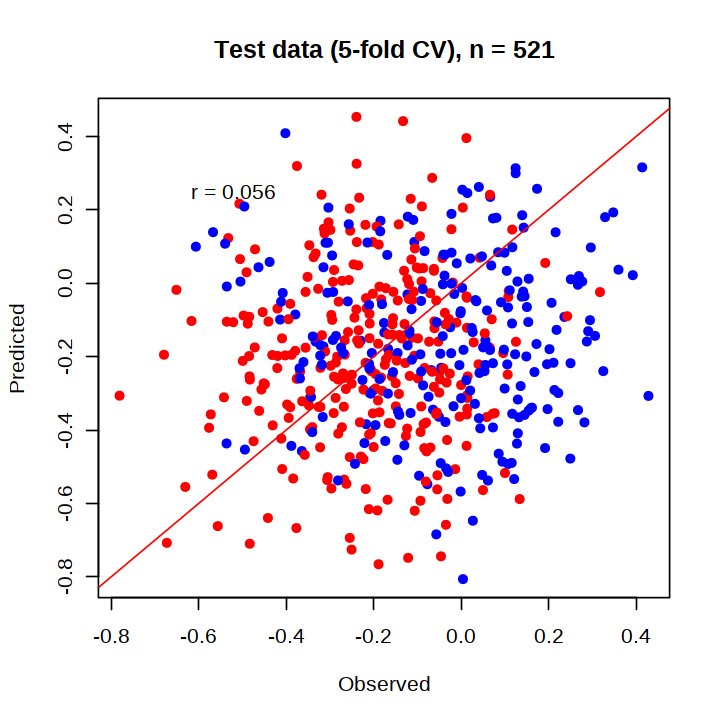

In [488]:
y_test <- test_preds_all
# x_test <- apply(apply(as.matrix(ol_marg[match(names(test_preds_all), ol_marg$rowname),c('log_nsc','log_ipc')]), 2, function(x) (x - min(x))/(max(x) - min(x))), 1, diff)
x_test <- test_obs_all

plot(x_test, y_test, col = ifelse(names(test_preds_all) %in% ipc_pc_rn, 'blue', 'red'), pch = 16, main = paste0('Test data (5-fold CV), n = ', length(test_preds_all)), xlab = 'Observed', ylab = 'Predicted')
text(-0.52,0.25, labels = paste0('r = ', signif(cor(x_test, y_test, method = 'spearman'), 2)))
abline(0,1,col='red')

In [490]:
mmm <- apply(as.matrix(ol_marg[match(iq_cv_ls[[i]]$test_peaks, ol_marg$rowname),c('log_nsc','log_ipc')]), 2, function(x) (x - min(x))/(max(x) - min(x)))

In [491]:
rownames(mmm) <- test_peaks

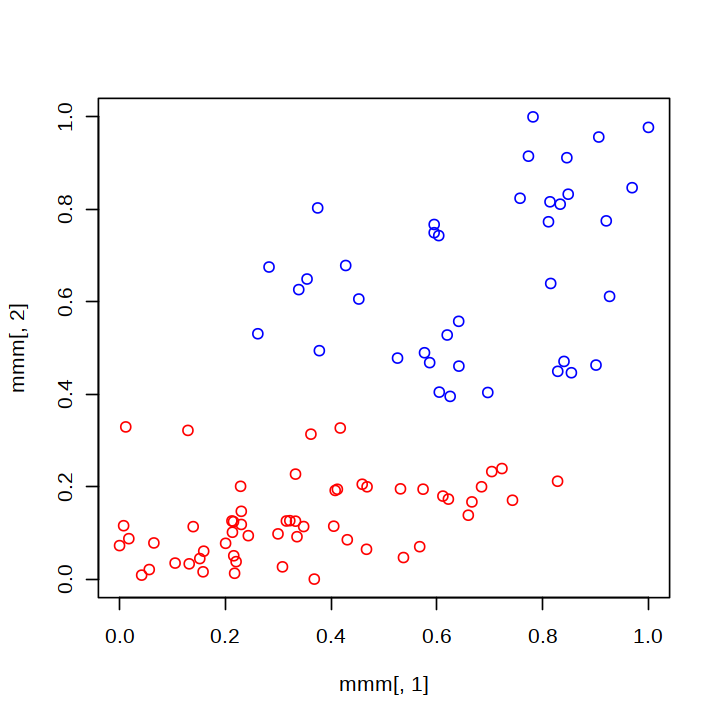

In [492]:
plot(mmm[,1], mmm[,2], col = ifelse(rownames(mmm) %in% ipc_pc_rn, 'blue', 'red'))

In [350]:
# par(mfrow = c(1,2), mar = c(5,4,2,1))
# plot(rvb_tm@predicted_diff_score,rvb_tm@diff_score, col = ifelse(rownames(rvb_tm@additional_features) %in% ipc_pc_rn, 'blue', 'red'), pch = 16, main = paste0('Training data, n = ', length(train_peaks)), xlab = 'Observed', ylab = 'Predicted')
# text(-0.6,0.35, labels = paste0('r = ', signif(cor(rvb_tm@predicted_diff_score,rvb_tm@diff_score), 2)))
# abline(0,1,col='red')
# x_test <- rvb_tm_test@predicted_diff_score[test_peaks]
# y_test <- rvb_tm_test@diff_score[match(test_peaks, rownames(rvb_tm_test@additional_features))]
# plot(x_test, y_test, col = ifelse(test_peaks %in% ipc_pc_rn, 'blue', 'red'), pch = 16, main = paste0('Test data (no CV), n = ', length(test_peaks)), xlab = 'Observed', ylab = 'Predicted')
# text(-0.52,0.35, labels = paste0('r = ', signif(cor(x_test, y_test), 2)))
# abline(0,1,col='red')

In [304]:
iceqream::plot_traj_model_report(rvb_tm, filename = './output/MPRA/red_vs_blue_iq_model_report.pdf')

i Plotting 14 motifs

Warning message:
"The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.
i The deprecated feature was likely used in the ggseqlogo package.
  Please report the issue at <https://github.com/omarwagih/ggseqlogo/issues>."
i Plotting motif "HOMER.JunD"

i Plotting motif "e3"

i Plotting motif "JASPAR.NEUROG1"

i Plotting motif "HOCOMOCO.MYCN_MOUSE.H11MO.0.A"

i Plotting motif "e2"

i Plotting motif "HOCOMOCO.OLIG2_HUMAN.H11MO.0.B"

i Plotting motif "e4"

i Plotting motif "JASPAR.TCF12"

i Plotting motif "HOCOMOCO.MYB_HUMAN.H11MO.0.A"

i Plotting motif "HOCOMOCO.SOX5_HUMAN.H11MO.0.C"

i Plotting motif "e1"

i Plotting motif "HOCOMOCO.NF2L1_HUMAN.H11MO.0.C"

i Plotting motif "HOMER.Olig2"

i Plotting motif "JASPAR.Nr1H2"

Warning message in stats::ks.test(plot_df$observed[plot_df$energy == "0-3"], plot_df$observed[plot_df$energy == :
"cannot compute exact p-value with ties"
Warning message in stats::ks.test(plot_df$observed[plot_

In [ ]:
prego_pssms <- lapply()

## Get cell type-specific peaks

In [680]:
source('./scripts/util.r')

In [666]:
ct_tracks

[1] "mmcortex_nsc_marginal"     "mmcortex_ipc_marginal"    
[3] "mmcortex_cpn_l23_marginal" "mmcortex_cpn_l56_marginal"
[5] "mmcortex_cthpn_marginal"   "mmcortex_scpn_marginal"

In [752]:
cfupn_peaks_df <-amos_peak_calling_function(trk = "mmcortex_cthpn_marginal", canonical = F)
cpnl23_peaks_df <-amos_peak_calling_function(trk = "mmcortex_cpn_l23_marginal", canonical = F)

astro_peaks_df <-amos_peak_calling_function(trk = "mmcortex_astrocytes_marginal", canonical = F)
oligo_peaks_df <-amos_peak_calling_function(trk = "mmcortex_OPCs_marginal", canonical = F)
nsc_peaks_df <-amos_peak_calling_function(trk = "mmcortex_nsc_marginal", canonical = F)

nei_cfupn_mcp <- gintervals.neighbors(cfupn_peaks_df, as.data.frame(mcp), mindist = 0, maxdist = 0, maxneighbors = 1e+6)
nei_cpn_mcp <- gintervals.neighbors(cpnl23_peaks_df, as.data.frame(mcp), mindist = 0, maxdist = 0, maxneighbors = 1e+6)
nei_astro_mcp <- gintervals.neighbors(astro_peaks_df, as.data.frame(mcp), mindist = 0, maxdist = 0, maxneighbors = 1e+6)
nei_oligo_mcp <- gintervals.neighbors(oligo_peaks_df, as.data.frame(mcp), mindist = 0, maxdist = 0, maxneighbors = 1e+6)
nei_nsc_mcp <- gintervals.neighbors(nsc_peaks_df, as.data.frame(mcp), mindist = 0, maxdist = 0, maxneighbors = 1e+6)

cfupn_peaks_df$is_in <- cfupn_peaks_df$intervalID %in% nei_cfupn_mcp$intervalID
cpnl23_peaks_df$is_in <- cpnl23_peaks_df$intervalID %in% nei_cpn_mcp$intervalID
astro_peaks_df$is_in <- astro_peaks_df$intervalID %in% nei_astro_mcp$intervalID
oligo_peaks_df$is_in <- oligo_peaks_df$intervalID %in% nei_oligo_mcp$intervalID

nsc_peaks_df$is_in <- nsc_peaks_df$intervalID %in% nei_nsc_mcp$intervalID

length(which(nsc_peaks_df$mmcortex_nsc_marginal[!nsc_peaks_df$is_in] > mean(nsc_peaks_df$mmcortex_nsc_marginal[nsc_peaks_df$is_in])))

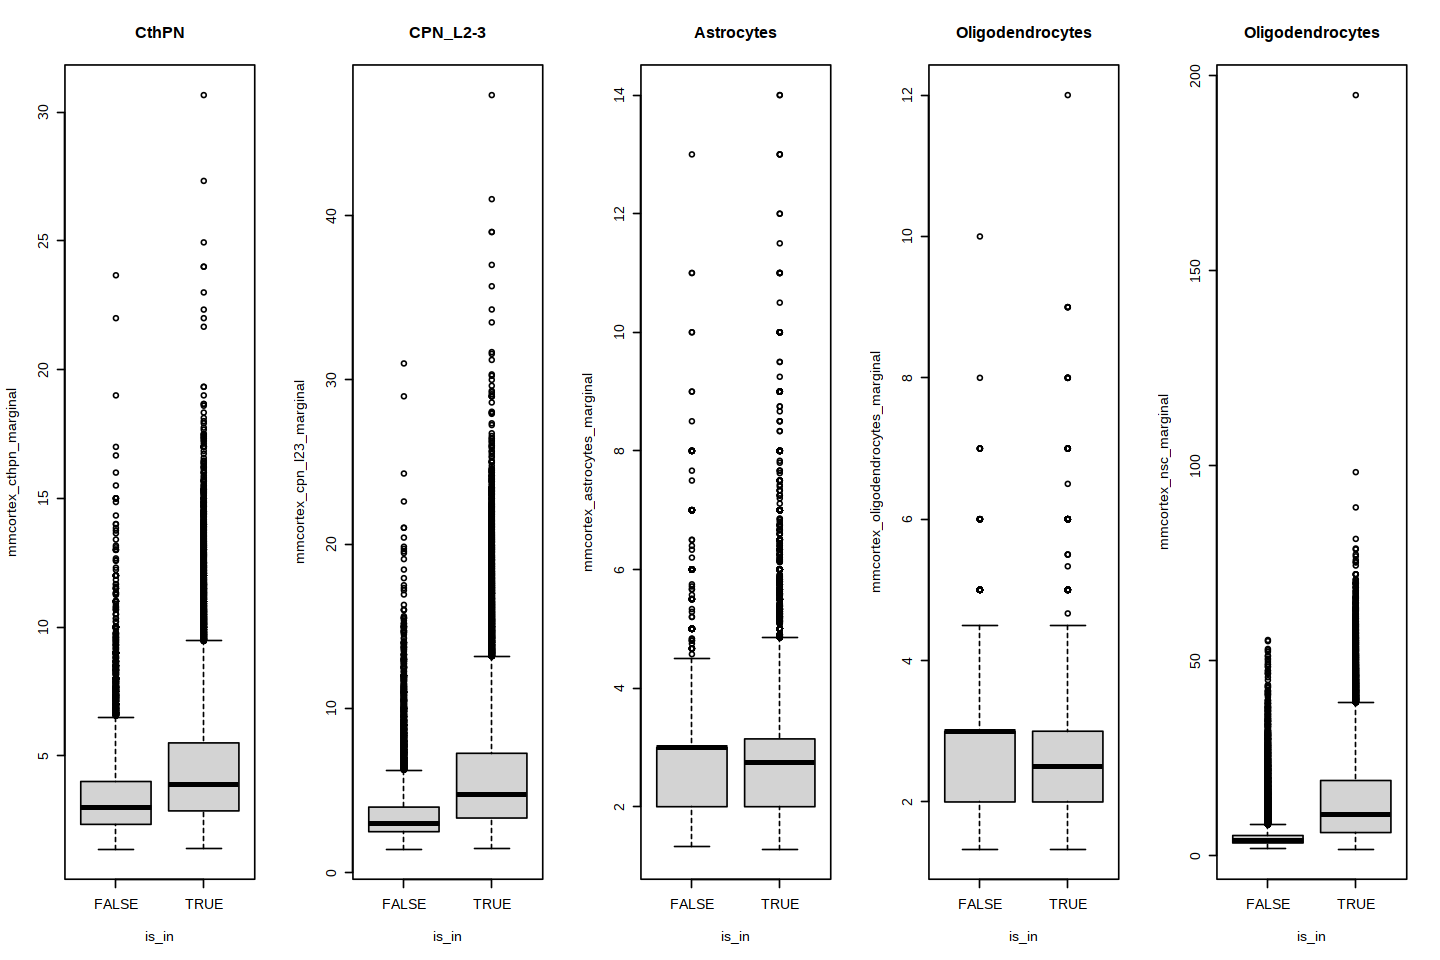

In [758]:
par(mfrow = c(1,5))
boxplot(mmcortex_cthpn_marginal ~ is_in, data = cfupn_peaks_df, main = 'CthPN')
boxplot(mmcortex_cpn_l23_marginal ~ is_in, data = cpnl23_peaks_df, main = 'CPN_L2-3')
boxplot(mmcortex_astrocytes_marginal ~ is_in, data = astro_peaks_df, main = 'Astrocytes')
boxplot(mmcortex_OPCs_marginal ~ is_in, data = oligo_peaks_df, main = 'OPCs')
boxplot(mmcortex_nsc_marginal ~ is_in, data = nsc_peaks_df, main = 'OPCs')

In [699]:
table(mcmd$cell_type)
# /sum(table(mcmd$cell_type))


      Astrocytes         CPN_L2-3         CPN_L5_6            CthPN 
               6               98               46               36 
          iCfuPN       iCPN_early        iCPN_late       iCPN/CfuPN 
              45              129              118              122 
             IPC          IPC_cyc              NSC OPCs 
             200               36              208                2 
            SCPN 
              45 

In [695]:
nrow(cfupn_peaks_df)

[1] 129934

In [754]:
length(setdiff(nsc_peaks_df$intervalID, nei_nsc_mcp$intervalID))

[1] 87085

In [692]:
length(setdiff(cfupn_peaks_df$intervalID, nei_cfupn_mcp$intervalID))

[1] 61584

In [725]:
length(setdiff(cpnl23_peaks_df$intervalID, nei_cpn_mcp$intervalID))

[1] 55861

In [726]:
length(setdiff(astro_peaks_df$intervalID, nei_astro_mcp$intervalID))

[1] 24216

In [727]:
length(setdiff(oligo_peaks_df$intervalID, nei_oligo_mcp$intervalID))

[1] 4720

In [756]:
table(nsc_peaks_df$is_in)


FALSE  TRUE 
87085 79656 

In [755]:
length(which(nsc_peaks_df$mmcortex_nsc_marginal[!nsc_peaks_df$is_in] > mean(nsc_peaks_df$mmcortex_nsc_marginal[nsc_peaks_df$is_in])))

[1] 905

In [696]:
length(which(cfupn_peaks_df$mmcortex_cthpn_marginal[!cfupn_peaks_df$is_in] > mean(cfupn_peaks_df$mmcortex_cthpn_marginal[cfupn_peaks_df$is_in])))

[1] 6101

In [728]:
length(which(cpnl23_peaks_df$mmcortex_cpn_l23_marginal[!cpnl23_peaks_df$is_in] > mean(cpnl23_peaks_df$mmcortex_cpn_l23_marginal[cpnl23_peaks_df$is_in])))

[1] 2941

In [729]:
length(which(astro_peaks_df$mmcortex_astrocytes_marginal[!astro_peaks_df$is_in] > mean(astro_peaks_df$mmcortex_astrocytes_marginal[astro_peaks_df$is_in])))

[1] 14313

In [730]:
length(which(oligo_peaks_df$mmcortex_OPCs_marginal[!oligo_peaks_df$is_in] > mean(oligo_peaks_df$mmcortex_OPCs_marginal[oligo_peaks_df$is_in])))

[1] 3249

In [737]:
nei_astro_not_in_oligo_not_in <- gintervals.neighbors(astro_peaks_df[!astro_peaks_df$is_in,], oligo_peaks_df[!oligo_peaks_df$is_in,], mindist = 0, maxdist = 0, maxneighbors = 1e+6)

In [745]:
nei_cfupn_not_in_cpn_not_in <- gintervals.neighbors(cfupn_peaks_df[!cfupn_peaks_df$is_in,], cpnl23_peaks_df[!cpnl23_peaks_df$is_in,], mindist = 0, maxdist = 0, maxneighbors = 1e+6)

In [738]:
nrow(astro_peaks_df[!astro_peaks_df$is_in,])
nrow(oligo_peaks_df[!oligo_peaks_df$is_in,])

[1] 24216

[1] 4720

In [747]:
nrow(cfupn_peaks_df[!cfupn_peaks_df$is_in,])
nrow(cpnl23_peaks_df[!cpnl23_peaks_df$is_in,])

[1] 61584

[1] 55861

In [742]:
nrow(nei_astro_not_in_oligo_not_in)

[1] 1093

In [746]:
nrow(nei_cfupn_not_in_cpn_not_in)

[1] 17624

In [743]:
head(nei_astro_not_in_oligo_not_in)

,chrom,start,end,mmcortex_astrocytes_marginal,intervalID,is_in,chrom1,start1,end1,mmcortex_OPCs_marginal,intervalID1,is_in1,dist
,<fct>,<dbl>,<dbl>,<dbl>,<int>,<lgl>,<fct>,<dbl>,<dbl>,<dbl>,<int>,<lgl>,<dbl>
1,chr1,5017940,5018240,2.666667,23,FALSE,chr1,5017980,5018280,3.000000,9,FALSE,0
2,chr1,9943600,9943900,2.800000,80,FALSE,chr1,9943600,9943900,1.666667,30,FALSE,0
3,chr1,12706340,12706640,2.250000,116,FALSE,chr1,12706280,12706580,3.000000,42,FALSE,0
4,chr1,17097240,17097540,2.500000,204,FALSE,chr1,17097240,17097540,3.000000,77,FALSE,0
5,chr1,20302520,20302820,2.000000,226,FALSE,chr1,20302760,20303060,4.000000,85,FALSE,0
6,chr1,22263660,22263960,2.500000,272,FALSE,chr1,22263840,22264140,3.000000,107,FALSE,0


[1] 0.13489

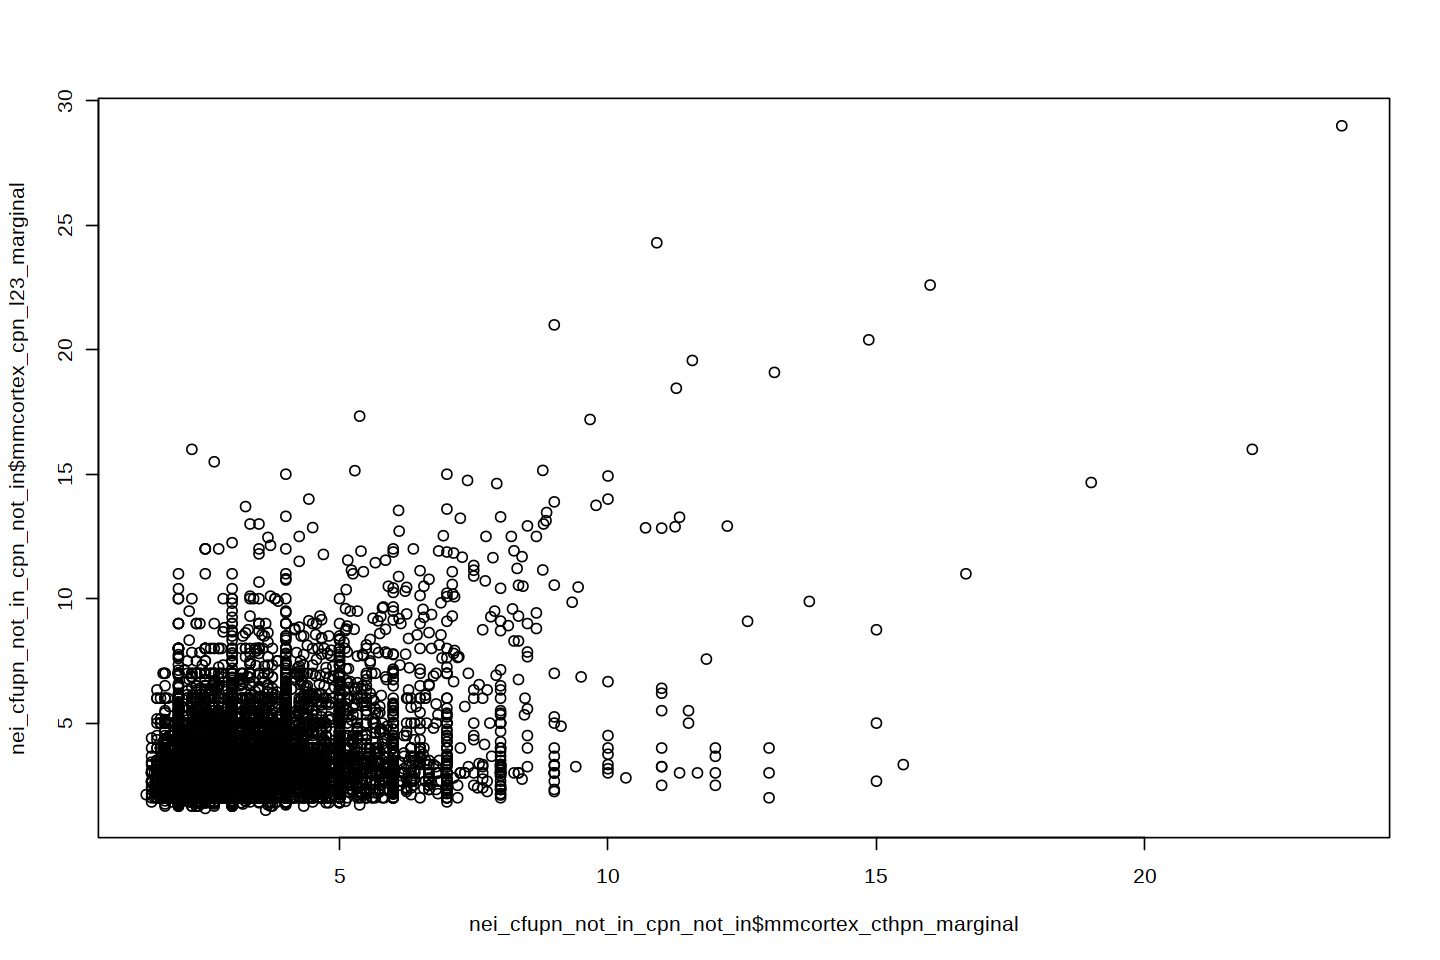

In [748]:
cor(nei_cfupn_not_in_cpn_not_in$mmcortex_cthpn_marginal, nei_cfupn_not_in_cpn_not_in$mmcortex_cpn_l23_marginal, method = 'spearman')
plot(nei_cfupn_not_in_cpn_not_in$mmcortex_cthpn_marginal, nei_cfupn_not_in_cpn_not_in$mmcortex_cpn_l23_marginal)

In [749]:
quantile(nei_cfupn_not_in_cpn_not_in$mmcortex_cthpn_marginal)
quantile(nei_cfupn_not_in_cpn_not_in$mmcortex_cpn_l23_marginal)

0%       25%       50%       75%      100% 
 1.400000  2.333333  3.000000  3.800000 23.666666

0%  25%  50%  75% 100% 
 1.5  2.6  3.0  4.0 29.0

In [750]:
quantile(cfupn_peaks_df$mmcortex_cthpn_marginal)
quantile(cpnl23_peaks_df$mmcortex_cpn_l23_marginal)

0%      25%      50%      75%     100% 
 1.37500  2.50000  3.25000  4.40000 30.66667

0%       25%       50%       75%      100% 
 1.444444  3.000000  3.818182  5.666667 47.333332

[1] -0.0154477

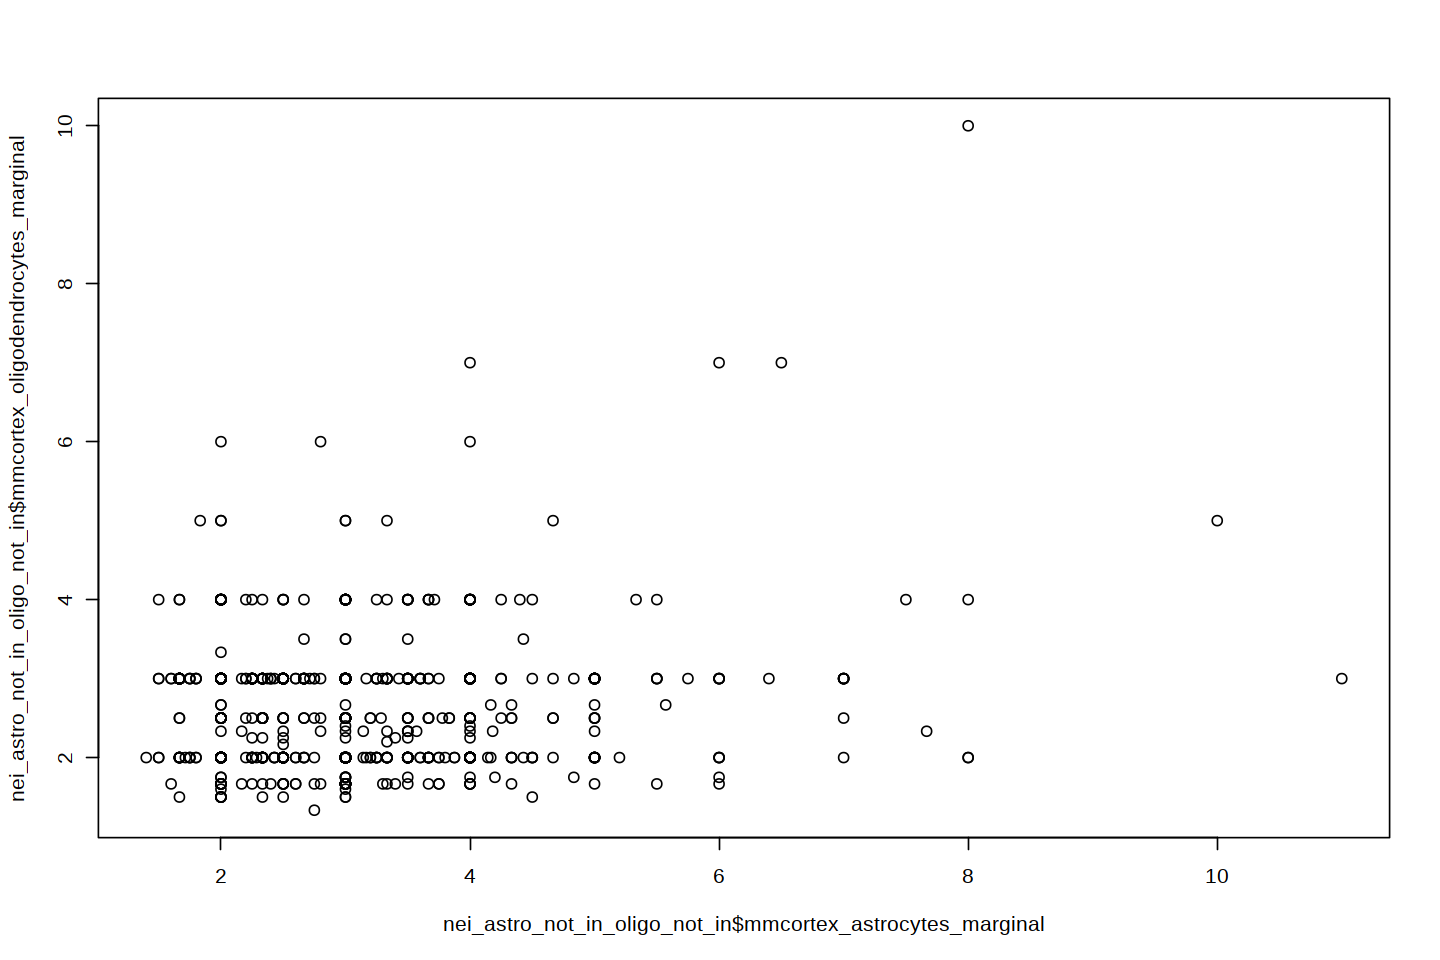

In [744]:
cor(nei_astro_not_in_oligo_not_in$mmcortex_astrocytes_marginal, nei_astro_not_in_oligo_not_in$mmcortex_OPCs_marginal, method = 'spearman')
plot(nei_astro_not_in_oligo_not_in$mmcortex_astrocytes_marginal, nei_astro_not_in_oligo_not_in$mmcortex_OPCs_marginal)

In [672]:
gquantiles(expr = 'mmcortex_cthpn_marginal', percentiles = c(seq(0,900,100), 950, 990, 999, 1000)/1000, iterator = 20)

0      0.1      0.2      0.3      0.4      0.5      0.6      0.7 
 1.00000  1.00000  1.00000  1.00000  1.00000  1.00000  1.00000  1.00000 
     0.8      0.9     0.95     0.99    0.999        1 
 1.00000  1.80000  2.00000  3.75000  7.12500 30.66667

In [673]:
gquantiles(expr = 'mmcortex_cpn_l23_marginal', percentiles = c(seq(0,900,100), 950, 990, 999, 1000)/1000, iterator = 20)

0       0.1       0.2       0.3       0.4       0.5       0.6       0.7 
 1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000 
      0.8       0.9      0.95      0.99     0.999         1 
 1.200000  2.000000  2.250000  4.666667 10.250000 47.333332

In [674]:
gquantiles(expr = 'mmcortex_cpn_l56_marginal', percentiles = c(seq(0,900,100), 950, 990, 999, 1000)/1000, iterator = 20)

0       0.1       0.2       0.3       0.4       0.5       0.6       0.7 
 1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000 
      0.8       0.9      0.95      0.99     0.999         1 
 1.000000  2.000000  2.000000  4.000000  7.916667 51.000000

In [675]:
gquantiles(expr = 'mmcortex_scpn_marginal', percentiles = c(seq(0,900,100), 950, 990, 999, 1000)/1000, iterator = 20)

0       0.1       0.2       0.3       0.4       0.5       0.6       0.7 
 1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000 
      0.8       0.9      0.95      0.99     0.999         1 
 1.000000  2.000000  2.000000  4.000000  8.333333 35.000000

In [676]:
gquantiles(expr = 'mmcortex_ipc_marginal', percentiles = c(seq(0,900,100), 950, 990, 999, 1000)/1000, iterator = 20)

0        0.1        0.2        0.3        0.4        0.5        0.6 
  1.000000   1.000000   1.000000   1.000000   1.000000   1.000000   1.000000 
       0.7        0.8        0.9       0.95       0.99      0.999          1 
  1.000000   1.500000   2.000000   2.888889   8.076923  25.294117 111.750000

In [677]:
gquantiles(expr = 'mmcortex_nsc_marginal', percentiles = c(seq(0,900,100), 950, 990, 999, 1000)/1000, iterator = 20)

0        0.1        0.2        0.3        0.4        0.5        0.6 
  1.000000   1.000000   1.000000   1.000000   1.000000   1.000000   1.000000 
       0.7        0.8        0.9       0.95       0.99      0.999          1 
  1.000000   1.500000   2.000000   2.666667   7.625000  23.933332 195.000000

In [669]:
head(cfupn_peaks)

,chrom,start,end,mmcortex_cthpn_marginal,intervalID
,<fct>,<dbl>,<dbl>,<dbl>,<int>
8,chr1,3000080,3000380,1,1
25,chr1,3000680,3000980,1,2
49,chr1,3002980,3003280,1,3
64,chr1,3003340,3003640,1,4
114,chr1,3004340,3004640,1,5
139,chr1,3005360,3005660,1,6


In [668]:
cfupn_peaks_can <-amos_peak_calling_function(trk = "mmcortex_cthpn_marginal", q = .95, canonical = T)

9%...
19%...
28%...
42%...
52%...
61%...
71%...
80%...
90%...
100%



In [ ]:
cpn_peaks <-amos_peak_calling_function(trk = "mmcortex_cthpn_marginal", q = .95, canonical = F)

## Check total marginal for neighboring peaks

In [319]:
head(ct_tracks_on_manifold)

,chrom,start,end,mmcortex_nsc_marginal,mmcortex_ipc_marginal,mmcortex_cpn_l23_marginal,mmcortex_cpn_l56_marginal,mmcortex_cthpn_marginal,mmcortex_scpn_marginal,intervalID
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,chr1,3094897,3095163,13.867403,13.966102,3.505747,2.305556,1.764706,1.851852,1
2,chr1,3113637,3113903,1.560976,1.736842,2.369048,1.700000,2.890000,3.504504,2
3,chr1,3120337,3120603,1.428571,1.672131,5.859873,4.741722,3.679688,4.696552,3
4,chr1,3121357,3121623,1.822581,1.472727,2.191781,1.542373,2.829545,2.600000,4
5,chr1,3210277,3210543,2.060976,5.546762,1.055556,1.100000,1.200000,1.000000,5
6,chr1,3399517,3399783,4.404959,3.360000,1.150000,1.187500,1.352941,1.150000,6


In [15]:
ct_tracks <- c('mmcortex_nsc_marginal', 'mmcortex_ipc_marginal')
ol_marg <- gextract(ct_tracks,intervals =  orig_lib_a[,c('chrom', 'start', 'end')], iterator = orig_lib_a[,c('chrom', 'start', 'end')])
mcp_trim <- dplyr::mutate(mcp[,c('chrom', 'start', 'end')],start = start + 17, end = end - 17)

In [320]:
neighboring_intervs <- dplyr::mutate(orig_lib_a[match(neu_rn, orig_lib_a$rowname),], start = start - 5e+4 + (end - start)/2, end = end + 5e+4 - (end - start)/2)

In [321]:
head(neighboring_intervs)

rowname,chrom,start,end
<chr>,<chr>,<dbl>,<dbl>
Mature.seqs_unc.Mature_neurons_516,chr1,3070496,3145562
Mature.seqs_desc.Mature_neurons_1249,chr1,4342678,4417744
Mature.seqs_asc.Mature_neurons_1292,chr1,6270743,6345810
Mature.seqs_unc.Mature_neurons_1222,chr1,13524221,13599288
Mature.seqs_asc.Mature_neurons_2640,chr1,19455508,19530574
Mature.seqs_unc.Mature_neurons_1975,chr1,22144008,22219074


In [323]:
ct_tracks_on_neighboring_intervals <- gextract(ct_tracks,intervals =  neighboring_intervs[,2:4], iterator =neighboring_intervs[,2:4])

In [324]:
head(ct_tracks_on_neighboring_intervals)

,chrom,start,end,mmcortex_nsc_marginal,mmcortex_ipc_marginal,mmcortex_cpn_l23_marginal,mmcortex_cpn_l56_marginal,mmcortex_cthpn_marginal,mmcortex_scpn_marginal,intervalID
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,chr1,3070496,3145562,2.555929,2.441207,2.551808,2.244742,2.022905,2.182970,1
2,chr1,4342678,4417744,1.603015,1.230477,1.088172,1.044199,1.217647,1.216772,2
3,chr1,6270743,6345809,1.416726,1.492919,1.560304,1.436561,1.241287,1.275389,3
4,chr1,13524221,13599287,2.923785,3.026656,2.349887,2.180637,1.982810,2.198651,4
5,chr1,19455508,19530574,1.183693,1.093403,1.058212,1.042253,1.022305,1.036011,5
6,chr1,22144008,22219074,1.178158,1.255910,2.160955,1.869139,1.641544,1.836478,6


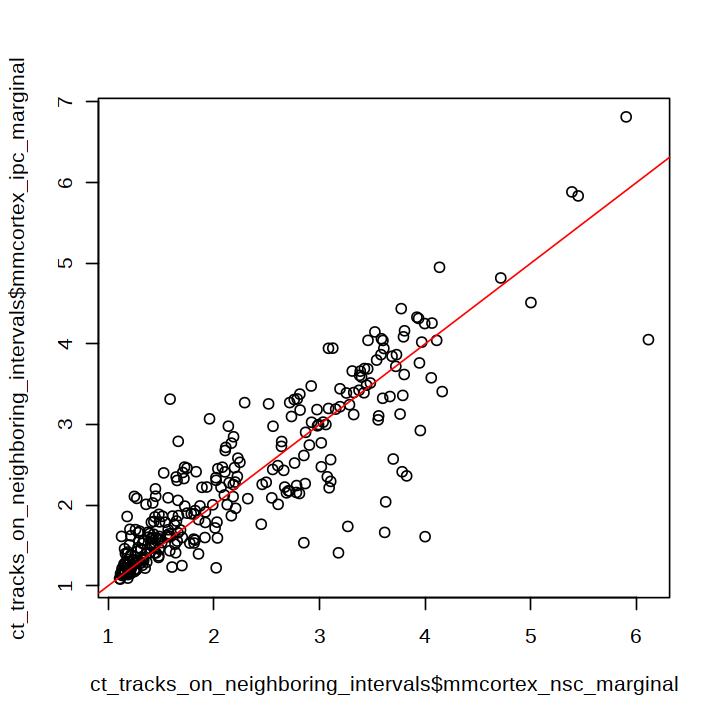

In [326]:
plot(ct_tracks_on_neighboring_intervals$mmcortex_nsc_marginal, ct_tracks_on_neighboring_intervals$mmcortex_ipc_marginal)
abline(0,1,col = 'red')

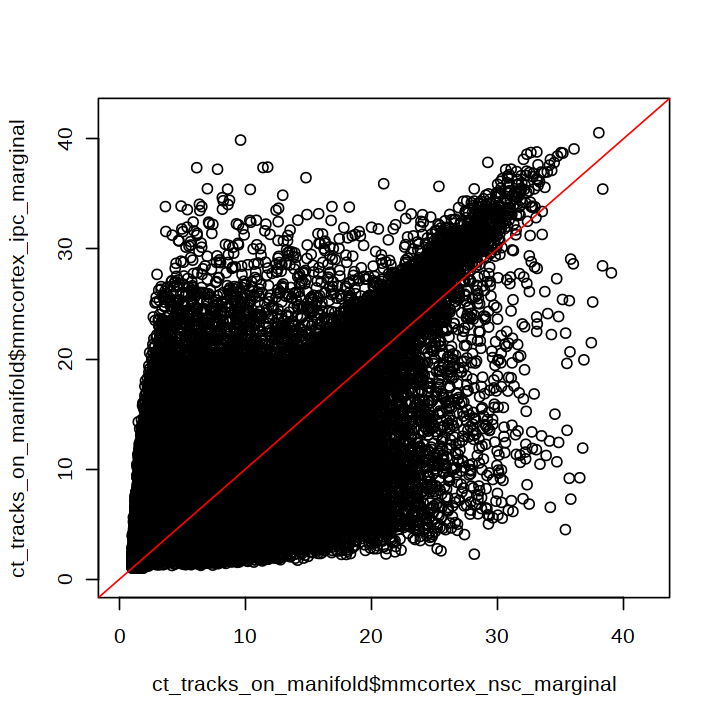

In [328]:
plot(ct_tracks_on_manifold$mmcortex_nsc_marginal, ct_tracks_on_manifold$mmcortex_ipc_marginal, xlim = c(0,42), ylim = c(0,42))
abline(0,1,col = 'red')

In [336]:
head(nsc_pca)

peak_name,atac_umi,rna_umi,r,rowname,new_class,is_ctxt,is_neu,is_anti_neu
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<lgl>,<lgl>
chr1:3113626-3113892,3008,0,NA,Mature.seqs_desc.Mature_neurons_1060,C,FALSE,FALSE,FALSE
chr1:3120363-3120629,2875,0,NA,Mature.seqs_unc.Mature_neurons_516,C,FALSE,TRUE,FALSE
chr1:3900384-3900650,365,137,NA,Mature.seqs_unc.Mature_neurons_374,C,FALSE,FALSE,FALSE
chr1:4392545-4392811,1307,48942,NA,Mature.seqs_desc.Mature_neurons_1249,C,FALSE,TRUE,FALSE
chr1:4543966-4544232,5154,60358,NA,NSC.seqs_asc.NSC_1875,B,FALSE,FALSE,FALSE
chr1:4934104-4934370,2698,70679,NA,shadow_chr19-40349777-40350042,C,FALSE,FALSE,FALSE


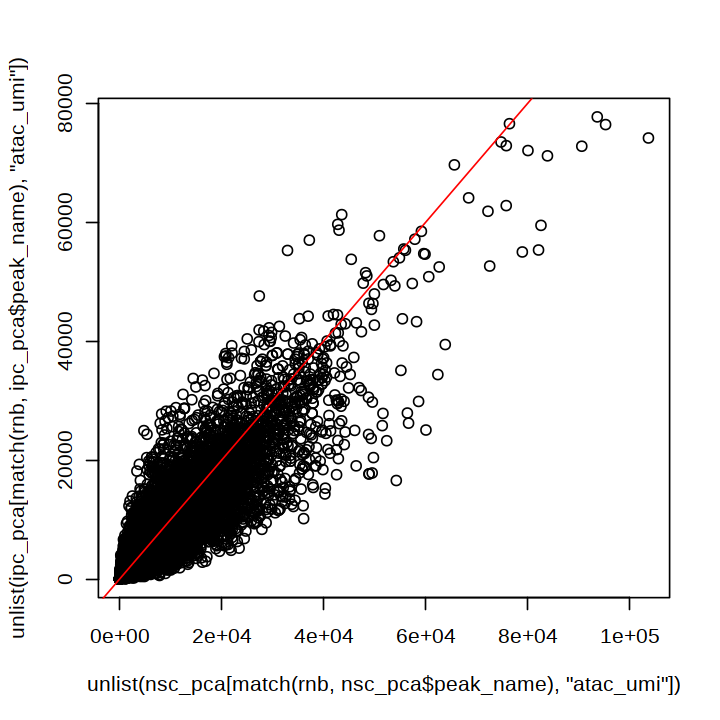

In [340]:
rnb <- intersect(nsc_pca$peak_name, ipc_pca$peak_name)
plot(unlist(nsc_pca[match(rnb, nsc_pca$peak_name),'atac_umi']), unlist(ipc_pca[match(rnb, ipc_pca$peak_name),'atac_umi']))
     # , xlim = c(0,42), ylim = c(0,42)
    # )
abline(0,1,col = 'red')

In [514]:
filt_na <- function(x) {y <- x; return(y[!is.na(y)])}

In [397]:
table(nsc_pca$peak_name %in% mcp$peak_name)


FALSE 
11905 

In [515]:
rnb <- intersect(nsc_pca$peak_name, ipc_pca$peak_name)
mcp_rnb <- filt_na(setNames(nei_orig_mcp$peak_name[match(nsc_pca$rowname[match(rnb, nsc_pca$peak_name)], nei_orig_mcp$rowname)], rnb))
smoothScatter(log2(1+unlist(nsc_pca[match(rnb, nsc_pca$peak_name),'rna_umi'])), log2(1+unlist(ipc_pca[match(rnb, ipc_pca$peak_name),'rna_umi'])))
     # , xlim = c(0,42), ylim = c(0,42)
    # )
abline(0,1,col = 'red')
abline(1,1,col = 'green')
abline(-1,1,col = 'green')

ERROR: Error in setNames(nei_orig_mcp$peak_name[match(nsc_pca$rowname[match(rnb, : object 'nei_orig_mcp' not found


In [248]:
rna_diff_vec <- setNames(log2(1+unlist(ipc_pca[match(rnb, ipc_pca$peak_name),'rna_umi'])) - log2(1+unlist(nsc_pca[match(rnb, nsc_pca$peak_name),'rna_umi'])), rnb)
crs_diff_rna <- names(rna_diff_vec[abs(rna_diff_vec) >= 2])

In [512]:
atac_diff_vec <- setNames(unlist(ipc_pca[match(rnb, ipc_pca$peak_name),'atac_umi']) - unlist(nsc_pca[match(rnb, nsc_pca$peak_name),'atac_umi']), rnb)
crs_diff_atac <- names(atac_diff_vec[abs(atac_diff_vec) >= 5e+3])

ERROR: Error in setNames(unlist(ipc_pca[match(rnb, ipc_pca$peak_name), "atac_umi"]) - : object 'rnb' not found


In [409]:
length(crs_diff_rna)
length(crs_diff_atac)

[1] 914

[1] 1978

In [410]:
length(intersect(crs_diff_rna,crs_diff_atac))

[1] 213

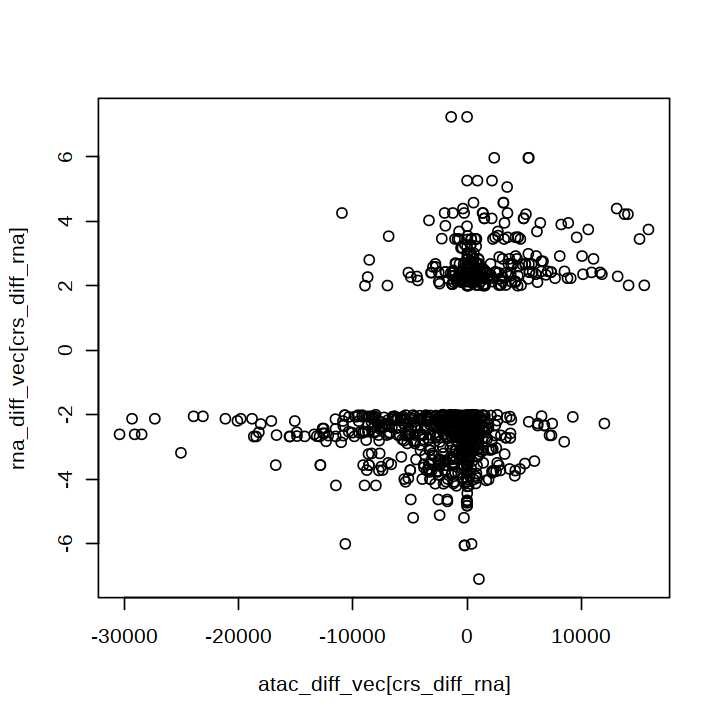

In [411]:
plot(atac_diff_vec[crs_diff_rna], rna_diff_vec[crs_diff_rna])

In [251]:
a_legc_avg_ct <- t(tgs_matrix_tapply(a_legc, mcmd$cell_type, mean))

In [252]:
delta_ipc_nsc <- setNames(a_legc_avg_ct[,'IPC'] - a_legc_avg_ct[,'NSC'], rownames(a_legc_avg_ct))

In [511]:
# png(file.path(wd, 'output/sequence_modeling/figs/delta_atac_vs_delta_proximal_atac.png'), h = 500, w = 600)
pdf(file.path(wd, 'output/sequence_modeling/figs/delta_atac_vs_delta_proximal_atac.pdf'), h = 500/71, w = 600/71)
par(las = 2, mar = c(13, 5, 3,1), cex.lab = 1.5)
boxplot_vec(xvec = atac_diff_vec[names(mcp_rnb)], yvec = delta_ipc_nsc[mcp_rnb], nm = 'Delta ATAC vs delta proximal ATAC', num_bins = 11, ylab = 'Delta ATAC')
title(xlab = 'Delta proximal IPC-NSC ATAC UMIs (50kbp)', line = 11)
text(1.5, 2, labels = paste0('cor = ', signif(cor(atac_diff_vec[names(mcp_rnb)], delta_ipc_nsc[mcp_rnb], method = 'spearman', use = 'pairwise.complete.obs'), 2)), cex = 1.5)
dev.off()

ERROR: Error in boxplot_vec(xvec = atac_diff_vec[names(mcp_rnb)], yvec = delta_ipc_nsc[mcp_rnb], : object 'atac_diff_vec' not found


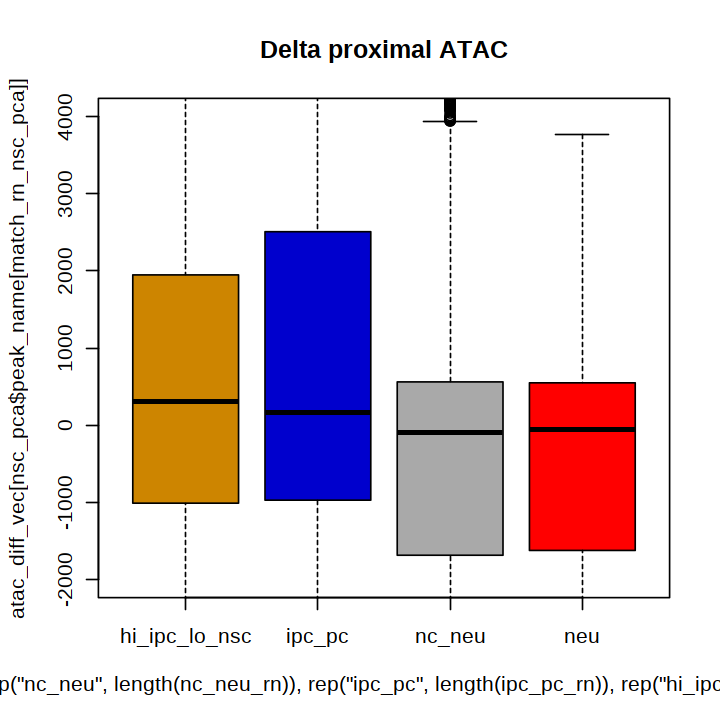

In [455]:
match_rn_nsc_pca <- match(c(neu_rn, nc_neu_rn, ipc_pc_rn, hi_ipc_lo_nsc_rn), nsc_pca$rowname)
boxplot(atac_diff_vec[nsc_pca$peak_name[match_rn_nsc_pca]] ~ c(rep('neu', length(neu_rn)), rep('nc_neu', length(nc_neu_rn)), rep('ipc_pc', length(ipc_pc_rn)), rep('hi_ipc_lo_nsc', length(hi_ipc_lo_nsc_rn))), ylim = c(-2e+3, 4e+3), 
        main = 'Delta proximal ATAC', col = rev(c('red', 'darkgray', col_key[['IPC']], 'orange3')))
# boxplot(atac_diff_vec[nsc_pca$peak_name[match_rn_nsc_pca]] ~ c(rep('neu', length(neu_rn)), rep('nc_neu', length(nc_neu_rn))), ylim = c(-2e+3, 2e+3), xlim = c(0,6))

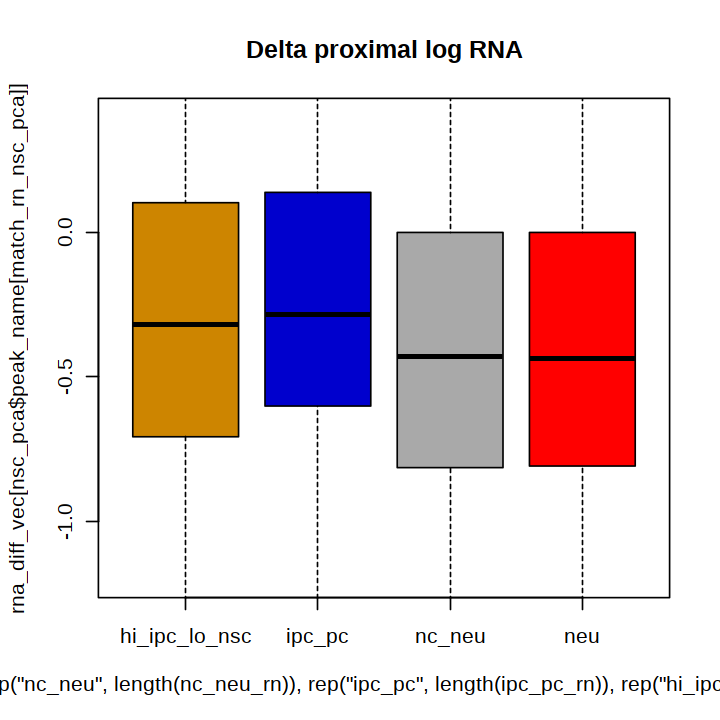

In [458]:
match_rn_nsc_pca <- match(c(neu_rn, nc_neu_rn, ipc_pc_rn, hi_ipc_lo_nsc_rn), nsc_pca$rowname)
boxplot(rna_diff_vec[nsc_pca$peak_name[match_rn_nsc_pca]] ~ c(rep('neu', length(neu_rn)), rep('nc_neu', length(nc_neu_rn)), rep('ipc_pc', length(ipc_pc_rn)), rep('hi_ipc_lo_nsc', length(hi_ipc_lo_nsc_rn))), ylim = c(-1.2,.4), 
        main = 'Delta proximal log RNA', col = rev(c('red', 'darkgray', col_key[['IPC']], 'orange3')))
# boxplot(atac_diff_vec[nsc_pca$peak_name[match_rn_nsc_pca]] ~ c(rep('neu', length(neu_rn)), rep('nc_neu', length(nc_neu_rn))), ylim = c(-2e+3, 2e+3), xlim = c(0,6))

[1] 0.1900717

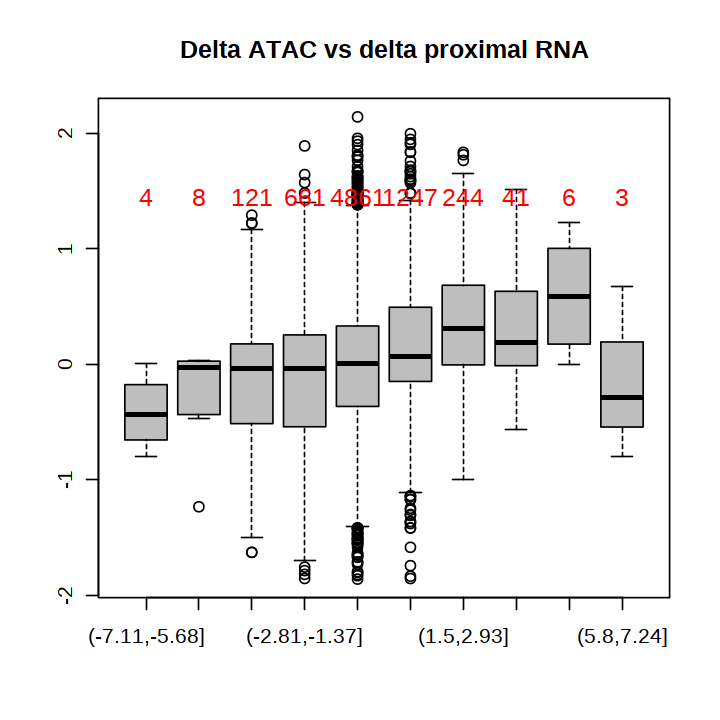

In [421]:
boxplot_vec(xvec = rna_diff_vec[names(mcp_rnb)], yvec = delta_ipc_nsc[mcp_rnb], nm = 'Delta ATAC vs delta proximal RNA', num_bins = 11)
cor(rna_diff_vec[names(mcp_rnb)], delta_ipc_nsc[mcp_rnb], method = 'spearman')

## Generate xgboost predictions for all ATAC peaks

In [27]:
load('./output/sequence_modeling/enhflow_model_n_motif=16_w_clustering.rda')

In [28]:
options(gmax.data.size = 1e+9)

In [29]:
rename_prego_motifs <- function(model, tfs_in) {
    amd <- prego::all_motif_datasets()
    amou <- unique(amd[,c('motif', 'motif_orig')])
    motif_clustering <- model@params$distilled_features
    prego_motifs_renamed <- sapply(names(model@motif_models), function(cni) {
        candidates <- motif_clustering$feat[motif_clustering$clust == cni]
        candidates <- setNames(candidates, unlist(purrr::map(stringr::str_split(amou$motif_orig[match(candidates, amou$motif)], '_'), 1)))
        candidates_all <- candidates[tolower(names(candidates)) %in% tolower(tfs_in)]
        # candidates_feats <- candidates[tolower(names(candidates)) %in% tolower(intersect(tfs_in, feats))]
        # if (length(candidates_feats) > 0) {
        #     return(candidates_feats[[1]])
        # } else
        if (length(candidates_all) > 0) {
            return(candidates_all[[1]])
        } else {
            return(candidates[[1]])
        }
    })
    return(prego_motifs_renamed) 
}

prego_motifs <- do.call('rbind', lapply(seq_along(tm_w_add_feat@motif_models), function(i) dplyr::mutate(tm_w_add_feat@motif_models[[i]]$pssm, motif = names(tm_w_add_feat@motif_models)[[i]])))
prego_ie <- prego::gextract_pwm(intervals = mcp, motifs = unique(prego_motifs$motif), dataset = prego_motifs)
prego_ie_mat <- subset(prego_ie, select = -c(chrom, start, end, peak_name))
rownames(prego_ie_mat) <- prego_ie$peak_name
colnames(prego_ie_mat) <- prego_motifs_renamed[colnames(prego_ie_mat)]

In [30]:
load('./output/sequence_modeling/dinucs_feat_peaks.rda')

In [31]:
preds_all <- do.call('rbind', lapply(xgb_cv_res, function(x) x[['contrib_meth']]))

In [32]:
dtest_prego_ie_mat <- cbind(prego_ie_mat, 'NSC_ATAC' = mean(quantile(rowMeans(a_legc_by_day_n[rownames(preds_all),]), c(0,1))),'methylation' = 0, 
                                        dinucs_per_peak[rownames(prego_ie_mat),intersect(colnames(dinucs_per_peak), colnames(preds_all))], 
                                        'GC content' = 0.05, 'prox_ATAC' = 10, 'prox_RNA' = 10)

In [33]:
pred_mcp <- setNames(predict(xgb_cv_res[[1]]$bstDMatrix_meth, xgb.DMatrix(as.matrix(dtest_prego_ie_mat)), predcontrib=FALSE, predinteraction = FALSE), rownames(dtest_prego_ie_mat))

## Check whether neighbors of peak categories are enriched for motifs

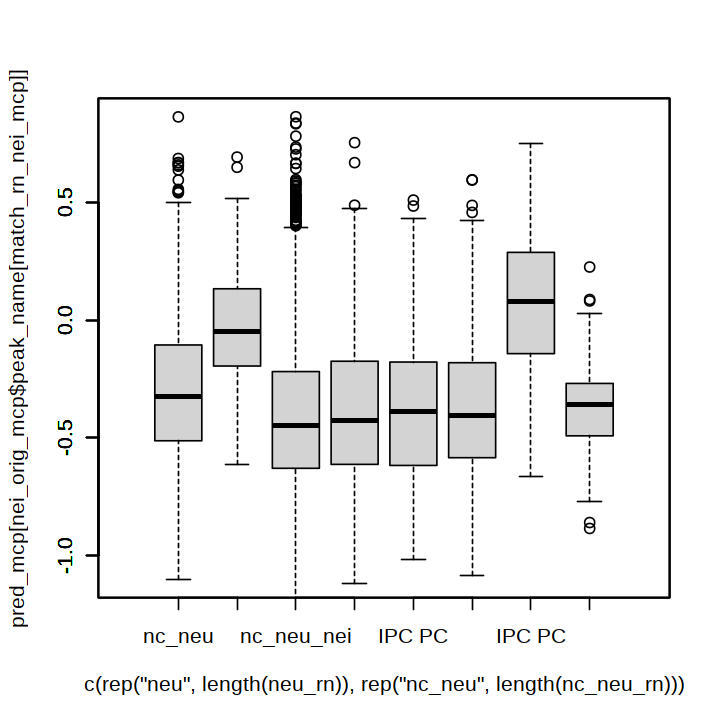

In [34]:
nei_orig_mcp <- gintervals.neighbors(dplyr::relocate(orig_lib_a, rowname, .after = end), as.data.frame(mcp), mindist = 0, maxdist = 0, maxneighbors = 1e+3)

options(repr.plot.width = 6)
options(repr.plot.height = 6)

nei_orig_peaks_f <- nei_orig_peaks[nei_orig_peaks$dist <= 5e+4,]

match_rn_nei_mcp <- match(c(neu_rn, nc_neu_rn), nei_orig_mcp$rowname)
boxplot(pred_mcp[nei_orig_mcp$peak_name[match_rn_nei_mcp]] ~ c(rep('neu', length(neu_rn)), rep('nc_neu', length(nc_neu_rn))), xlim = c(0,9), add = F, at = c(1,2))
match_rn_nei_peaks_f <- match(c(neu_rn, nc_neu_rn), nei_orig_peaks_f$rowname)
boxplot(pred_mcp[nei_orig_peaks_f$peak_name[match_rn_nei_peaks_f]] ~ c(rep('neu_nei', length(neu_rn)), rep('nc_neu_nei', length(nc_neu_rn))), add = T, at = c(3,4))

match_rn_nei_peaks_f <- match(c(ipc_pc_rn, hi_ipc_lo_nsc_rn), nei_orig_peaks_f$rowname)
boxplot(pred_mcp[nei_orig_peaks_f$peak_name[match_rn_nei_peaks_f]] ~ c(rep('IPC PC', length(ipc_pc_rn)), rep('hi_ipc_lo_nsc', length(hi_ipc_lo_nsc_rn))), add = T, at = c(5,6))
match_rn_nei_peaks_f <- match(c(ipc_pc_rn, hi_ipc_lo_nsc_rn), nei_orig_mcp$rowname)
boxplot(pred_mcp[nei_orig_mcp$peak_name[match_rn_nei_peaks_f]] ~ c(rep('IPC PC', length(ipc_pc_rn)), rep('hi_ipc_lo_nsc', length(hi_ipc_lo_nsc_rn))), add = T, at = c(7,8))

In [308]:
colnames(prego_ie_mat)

[1] "HOCOMOCO.MYB_HUMAN.H11MO.0.A"   "HOCOMOCO.OLIG2_HUMAN.H11MO.0.B"
 [3] "HOCOMOCO.GATA2_MOUSE.H11MO.0.A" "JOLMA.RFX4_di_DBD_1"           
 [5] "HOCOMOCO.TBP_MOUSE.H11MO.0.A"   "HOMER.JunD"                    
 [7] "JASPAR.Nr1H2"                   "HOCOMOCO.LEF1_HUMAN.H11MO.0.A" 
 [9] "HOCOMOCO.MYCN_MOUSE.H11MO.0.A"  "HOCOMOCO.NF2L1_HUMAN.H11MO.0.C"
[11] "HOMER.Olig2"                    "HOCOMOCO.SOX5_HUMAN.H11MO.0.C" 
[13] "JASPAR.TCF12"                   "JASPAR.NEUROG1"                
[15] "HOCOMOCO.TGIF1_HUMAN.H11MO.0.A" "JASPAR.EOMES"

In [310]:
mtt <- c('HOMER.Olig2', 'HOCOMOCO.OLIG2_HUMAN.H11MO.0.B', 'JASPAR.NEUROG1')

[1] 1
[1] 2
[1] 3
[1] 4


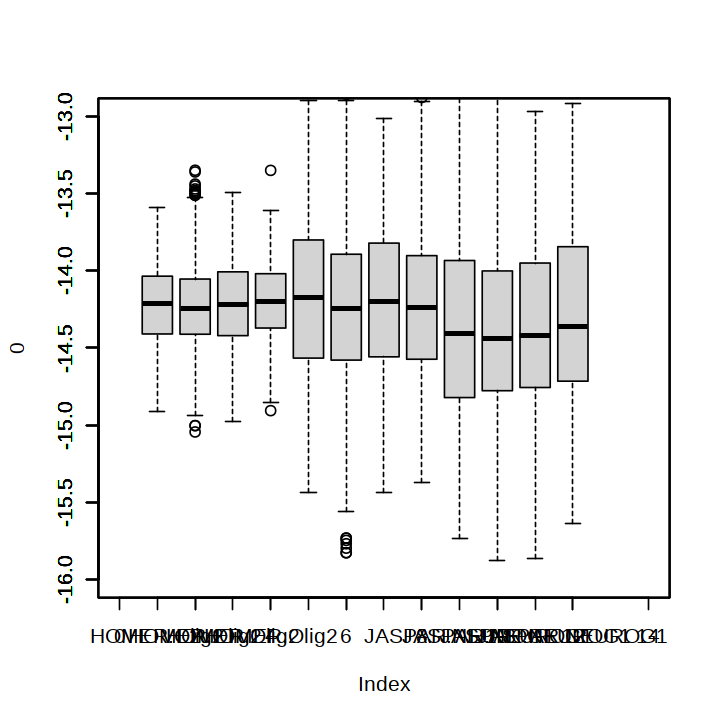

In [318]:
all_rn_list <- list(neu_rn, nc_neu_rn, ipc_pc_rn, hi_ipc_lo_nsc_rn)
plot(0, col = 'white', xlim = c(0,14), ylim = c(-16,-13))
ccc <- lapply(seq_along(all_rn_list), function(i) {
    x <- all_rn_list[[i]]
    pks_nei <- nei_orig_peaks_f$peak_name[match(x, nei_orig_peaks_f$rowname)]
    print(i)
    boxplot(prego_ie_mat[pks_nei,mtt], at = (i-1)+seq(1,length(all_rn_list)*length(mtt),length(all_rn_list)), add = T)
})

In [488]:
options(repr.plot.width = 15)
options(repr.plot.height = 5)